# 여성 정부지원 정책 데이터 기반 비즈니스 임팩트 EDA

이 노트북은 단순 통계가 아니라, **정책 탐색 서비스에서 사용자가 실제로 더 빠르게 혜택을 찾도록 만들 수 있는가**를 데이터로 검증하기 위해 만들었다.

- 비즈니스 문제: 정책은 많지만 사용자는 본인에게 맞는 정책을 찾기 어렵다.
- 데이터 가설: 대상유형, 지역, 지원형태, 신청방법, 연령조건, 지원금액 구조를 분석하면 검색/추천 우선순위를 개선할 수 있다.
- 검증 방식: 시각화 EDA, 카이제곱 검정, z-score 이상치 탐지, 금액 프록시 추출, TF-IDF 검색 비교, 분류 모델 교차검증을 사용한다.
- 결과 해석: 기술 자체보다 **사용자 탐색 시간 감소, 고가치 정책 노출, 정책 사각지대 발견**이라는 비즈니스 임팩트를 중심으로 정리한다.

> 기존 원본 파일은 읽기만 하고, 이 노트북 실행으로 생성되는 파일은 `business_impact_eda` 폴더 내부에만 저장한다.


In [1]:
# ============================================================
# 0. 환경 설정: pip 확인, 한글 폰트, 시각화 기본값
# ============================================================
from pathlib import Path
import os, sys, shutil, subprocess, platform, warnings

_cwd = Path.cwd().resolve()
if _cwd.name == "business_impact_eda":
    PROJECT_DIR = _cwd
elif (_cwd / "business_impact_eda").exists():
    PROJECT_DIR = _cwd / "business_impact_eda"
else:
    PROJECT_DIR = _cwd
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_DIR / ".mplconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

try:
    import pip  # noqa
except Exception:
    import ensurepip
    ensurepip.bootstrap(upgrade=True)

required = ["pandas", "numpy", "matplotlib", "seaborn", "scikit-learn", "scipy", "openpyxl"]
missing = []
for pkg in required:
    mod = "sklearn" if pkg == "scikit-learn" else pkg
    try:
        __import__(mod)
    except Exception:
        missing.append(pkg)
if missing:
    print("Missing packages:", missing)
    print("필요 시 실행:", sys.executable, "-m pip install", " ".join(missing))

if platform.system() == "Linux" and shutil.which("apt-get"):
    try:
        subprocess.run(["apt-get", "update", "-qq"], check=False)
        subprocess.run(["apt-get", "install", "-y", "fonts-nanum", "fonts-nanum-extra", "fonts-noto-cjk"], check=False, stdout=subprocess.DEVNULL)
    except Exception as e:
        print("Font install skipped:", e)

if "ipykernel" not in sys.modules:
    os.environ.setdefault("MPLBACKEND", "Agg")
else:
    try:
        get_ipython().run_line_magic("matplotlib", "inline")
        get_ipython().run_line_magic("config", "InlineBackend.figure_format = 'retina'")
    except Exception:
        pass

import numpy as np
import pandas as pd
import matplotlib as mpl
if "ipykernel" not in sys.modules:
    mpl.use("Agg", force=True)
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager as fm

shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)
Path(mpl.get_cachedir()).mkdir(parents=True, exist_ok=True)
try:
    fm._load_fontmanager(try_read_cache=False)
except Exception:
    pass

candidates = ["NanumBarunGothic", "NanumGothic", "Noto Sans CJK KR", "Malgun Gothic", "AppleGothic"]
avail = {n: any(n in f.name for f in fm.fontManager.ttflist) for n in candidates}
chosen = next((n for n in candidates if avail.get(n)), "DejaVu Sans")
plt.rcParams["font.family"] = [chosen]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid", font=chosen)
warnings.filterwarnings("ignore")

print("Using font:", chosen)
print("Project dir:", PROJECT_DIR)
print("Python:", sys.executable)


Using font: NanumGothic
Project dir: C:\Users\hyunj\Women-s-Government-Aid\business_impact_eda
Python: c:\Users\hyunj\anaconda3\python.exe


## 1. 데이터 로드와 분석 질문

자기소개서에서 보여줄 질문은 다음과 같다.

1. 어떤 사용자군/지역에 정책이 몰려 있는가?
2. 사용자가 체감하는 혜택은 어떤 지원형태에 집중되는가?
3. 신청 장벽은 어디서 발생하는가?
4. 요약/분류 구조가 검색 성능을 얼마나 개선하는가?
5. 모델을 쓴다면 왜 쓰는가?


In [2]:
# 원본 데이터는 읽기만 한다
root_candidates = [Path.cwd(), Path(".."), PROJECT_DIR.parent, Path(r"C:\\Users\\hyunj\\Women-s-Government-Aid")]
relative_candidates = [
    Path("match") / "정책큐레이션_통합데이터_v1.0.xlsx",
    Path("UI") / "정책큐레이션_통합데이터_v1.0.xlsx",
]

DATA_PATH = None
for root in root_candidates:
    for rel in relative_candidates:
        p = root / rel
        if p.exists():
            DATA_PATH = p
            break
    if DATA_PATH:
        break

assert DATA_PATH is not None, "정책큐레이션_통합데이터_v1.0.xlsx 파일을 찾지 못했습니다."
print("Data path:", DATA_PATH)

df_raw = pd.read_excel(DATA_PATH)
df = df_raw.copy()
print("shape:", df.shape)
display(df.head(3))
display(pd.DataFrame({
    "column": df.columns,
    "missing_rate": [df[c].isna().mean() for c in df.columns],
    "nunique": [df[c].nunique(dropna=True) for c in df.columns]
}).sort_values("missing_rate", ascending=False))


Data path: ..\match\정책큐레이션_통합데이터_v1.0.xlsx
shape: (1310, 20)


,대상유형,지역,제목,detail_url,신청기간,신청방법,접수기관,지원형태,지원대상,지원내용,문의처,기타,카테고리_분류,지원형태_분류,지원대상_원문,지원대상_초벌요약,지원내용_원문,지원내용_초벌요약,age_eff_ranges,age_has_rule
0,한부모,강원특별자치도,강릉의료원 보건의료 복지 통합지원 서비스,https://www.gov.kr/portal/rcvfvrSvc/dtlEx/O000...,상시신청,○ 기타\n - 전자공문,NaN,"현금(감면), 서비스(의료)","지원대상\n○ 국민기초생활수급자(생계, 의료, 주거, 교육 급여)\n\n○ 차상위계...",지원내용\n○ 의료비 지원\n - 질병치료와 관련한 강릉의료원 의료서비스 이용시 급...,보건의료복지통합지원팀 (☎033-610-1492),NaN,취약계층,"직접금전지원,감면할인지원,의료지원,서비스","(1) 국민기초생활수급자 ( 생계, 의료, 주거, 교육 급여 )\n(2) 차상위계층...","국민기초생활수급자 ( 생계, 의료, 주거, 교육 급여 ) 차상위계층 가구건강보험료 ...",(1) 의료비 지원\n - 질병치료와 관련한 강릉의료원 의료서비스 이용시 급여 본인...,의료비 및 만성질환 관리 및 모니터링,[],False
1,한부모,강원특별자치도,강원형 수선유지 주거급여 지원,https://www.gov.kr/portal/rcvfvrSvc/dtlEx/6420...,접수기관 별 상이,○ 방문 신청\n - 주민센터 : 주소지 읍면동 주민센터에 방문 신청\n - 시군 ...,"주민센터,시·군·구청",현물,"지원대상\n○ 기준 중위소득 50%이하 차상위계층 중 고령자, 장애인, 소년·소녀가...","지원내용\n○ 지원대상\n - 기준 중위소득 50%이하 차상위계층 중 고령자, 장애...",건축과 (☎033-249-3464),NaN,"한부모,고령자,취약계층","주거지원,물품지원","(1) 기준 중위소득 50%이하 차상위계층 중 고령자, 장애인, 소년·소녀가정, 다...","기준 중위소득 50%이하 차상위계층 중 고령자, 장애인, 소년·소녀가정, 다자녀 가...","(1) 해당사항\n - 기준 중위소득 50%이하 차상위계층 중 고령자, 장애인, 소...",가구당 최대 5백만원 지원 등,[],False
2,한부모,강원특별자치도,방학 중 아동급식 지원,https://www.gov.kr/portal/rcvfvrSvc/dtlEx/6530...,상시신청,거주지 관할 읍/면/동 행정복지센터에 방문 신청,주민센터,현물,지원대상\n(1) 아래의 어느 하나에 해당하는 아동으로서 결식우려가 있는 아동\n ...,"지원내용\n○ 지원연령: 18세 미만의 취학 아동(초등학교, 중학교, 고등학교 재학...",복지정책과 (☎033-249-2267),NaN,"한부모,임신/출산/육아,초/중/고등학생,취약계층","교육지원,물품지원",(1) 아래의 어느 하나에 해당하는 아동으로서 결식우려가 있는 아동\n - 국민기초...,아동복지프로그램을 통해 식사를 제공받는 경우 해당 식사분에 대하여 급식카드 등 다른...,"(1) 연령: 18세 미만의 취학 아동 ( 초등학교, 중학교, 고등학교 재학 ) 및...","18세 미만의 취학 아동 및 학교밖 청소년 지원유형은 아동급식카드, 지역아동센터지원...",[],False


,column,missing_rate,nunique
11,기타,0.984733,18
6,접수기관,0.068702,392
14,지원대상_원문,0.021374,1217
17,지원내용_초벌요약,0.021374,1236
16,지원내용_원문,0.021374,1245
15,지원대상_초벌요약,0.021374,1202
5,신청방법,0.018321,1098
7,지원형태,0.014504,132
3,detail_url,0.003053,1277
8,지원대상,0.002290,1241


In [3]:
# 분석용 파생변수
import re

text_cols = ["제목", "지원대상", "지원내용", "지원대상_초벌요약", "지원내용_초벌요약", "카테고리_분류", "지원형태_분류", "신청방법", "신청기간"]
for c in text_cols:
    if c in df.columns:
        df[c] = df[c].fillna("").astype(str)

def split_labels(x):
    if pd.isna(x) or str(x).strip() == "":
        return []
    return [v.strip() for v in re.split(r"[,/|]", str(x)) if v.strip()]

df["target_labels"] = df["대상유형"].apply(split_labels)
df["support_labels"] = df["지원형태_분류"].apply(split_labels)
df["category_labels"] = df["카테고리_분류"].apply(split_labels)

money_keywords = r"직접금전지원|현금|장학|수당|급여|지원금|보조금|감면|할인|이용권|바우처"
df["is_financial_benefit"] = df["지원형태_분류"].str.contains(money_keywords, regex=True, na=False)
df["is_direct_cash"] = df["지원형태_분류"].str.contains(r"직접금전지원|현금|지원금|수당|급여|장학", regex=True, na=False)
df["has_medical"] = df["지원형태_분류"].str.contains(r"의료", regex=True, na=False)
df["has_housing"] = df["지원형태_분류"].str.contains(r"주거", regex=True, na=False)
df["has_service"] = df["지원형태_분류"].str.contains(r"서비스", regex=True, na=False)
df["is_always_open"] = df["신청기간"].str.contains(r"상시", regex=True, na=False)
detail_text = df["detail_url"].fillna("").astype(str) if "detail_url" in df.columns else ""
df["has_online_apply"] = (df["신청방법"] + " " + detail_text).str.contains(r"온라인|인터넷|정부24|www|http", regex=True, na=False)
df["summary_len"] = (df["지원대상_초벌요약"] + " " + df["지원내용_초벌요약"]).str.len()
df["raw_text_len"] = (df["지원대상"] + " " + df["지원내용"]).str.len()
df["summary_compression_rate"] = 1 - (df["summary_len"] / df["raw_text_len"].replace(0, np.nan))

def amount_to_million(num, unit):
    n = float(str(num).replace(",", ""))
    if unit in ["억원", "억"]: return n * 100
    if unit == "천만원": return n * 10
    if unit == "백만원": return n
    if unit == "만원": return n / 100
    if unit == "원": return n / 1_000_000
    return np.nan

amount_pattern = re.compile(r"(\d+(?:,\d{3})*(?:\.\d+)?)\s*(억원|억|천만원|백만원|만원|원)")
def extract_max_amount_million(text):
    vals = [amount_to_million(num, unit) for num, unit in amount_pattern.findall(str(text))]
    vals = [v for v in vals if pd.notna(v) and 0 < v <= 1000]
    return max(vals) if vals else np.nan

df["amount_proxy_million"] = df["지원내용"].apply(extract_max_amount_million)
df.head(100).to_csv(OUTPUT_DIR / "analysis_table_preview.csv", index=False, encoding="utf-8-sig")

summary = pd.Series({
    "전체 정책 수": len(df),
    "대상유형 수": df["대상유형"].nunique(),
    "지역 수": df["지역"].nunique(),
    "금전성 혜택 비율": df["is_financial_benefit"].mean(),
    "직접금전 정책 비율": df["is_direct_cash"].mean(),
    "상시신청 비율": df["is_always_open"].mean(),
    "온라인 신청 단서 비율": df["has_online_apply"].mean(),
    "연령조건 보유 비율": df["age_has_rule"].mean() if "age_has_rule" in df.columns else np.nan,
    "금액 프록시 추출 정책 수": df["amount_proxy_million"].notna().sum(),
})
display(summary.to_frame("value"))


,value
전체 정책 수,1310.000000
대상유형 수,8.000000
지역 수,246.000000
금전성 혜택 비율,0.629008
직접금전 정책 비율,0.467176
상시신청 비율,0.691603
온라인 신청 단서 비율,0.993893
연령조건 보유 비율,0.391603
금액 프록시 추출 정책 수,469.000000


## 2. 커버리지 EDA

정책 추천 서비스에서는 많은 정책을 보여주는 것보다, 사용자가 속한 집단에서 실제 선택지가 충분한지를 확인하는 것이 중요하다.


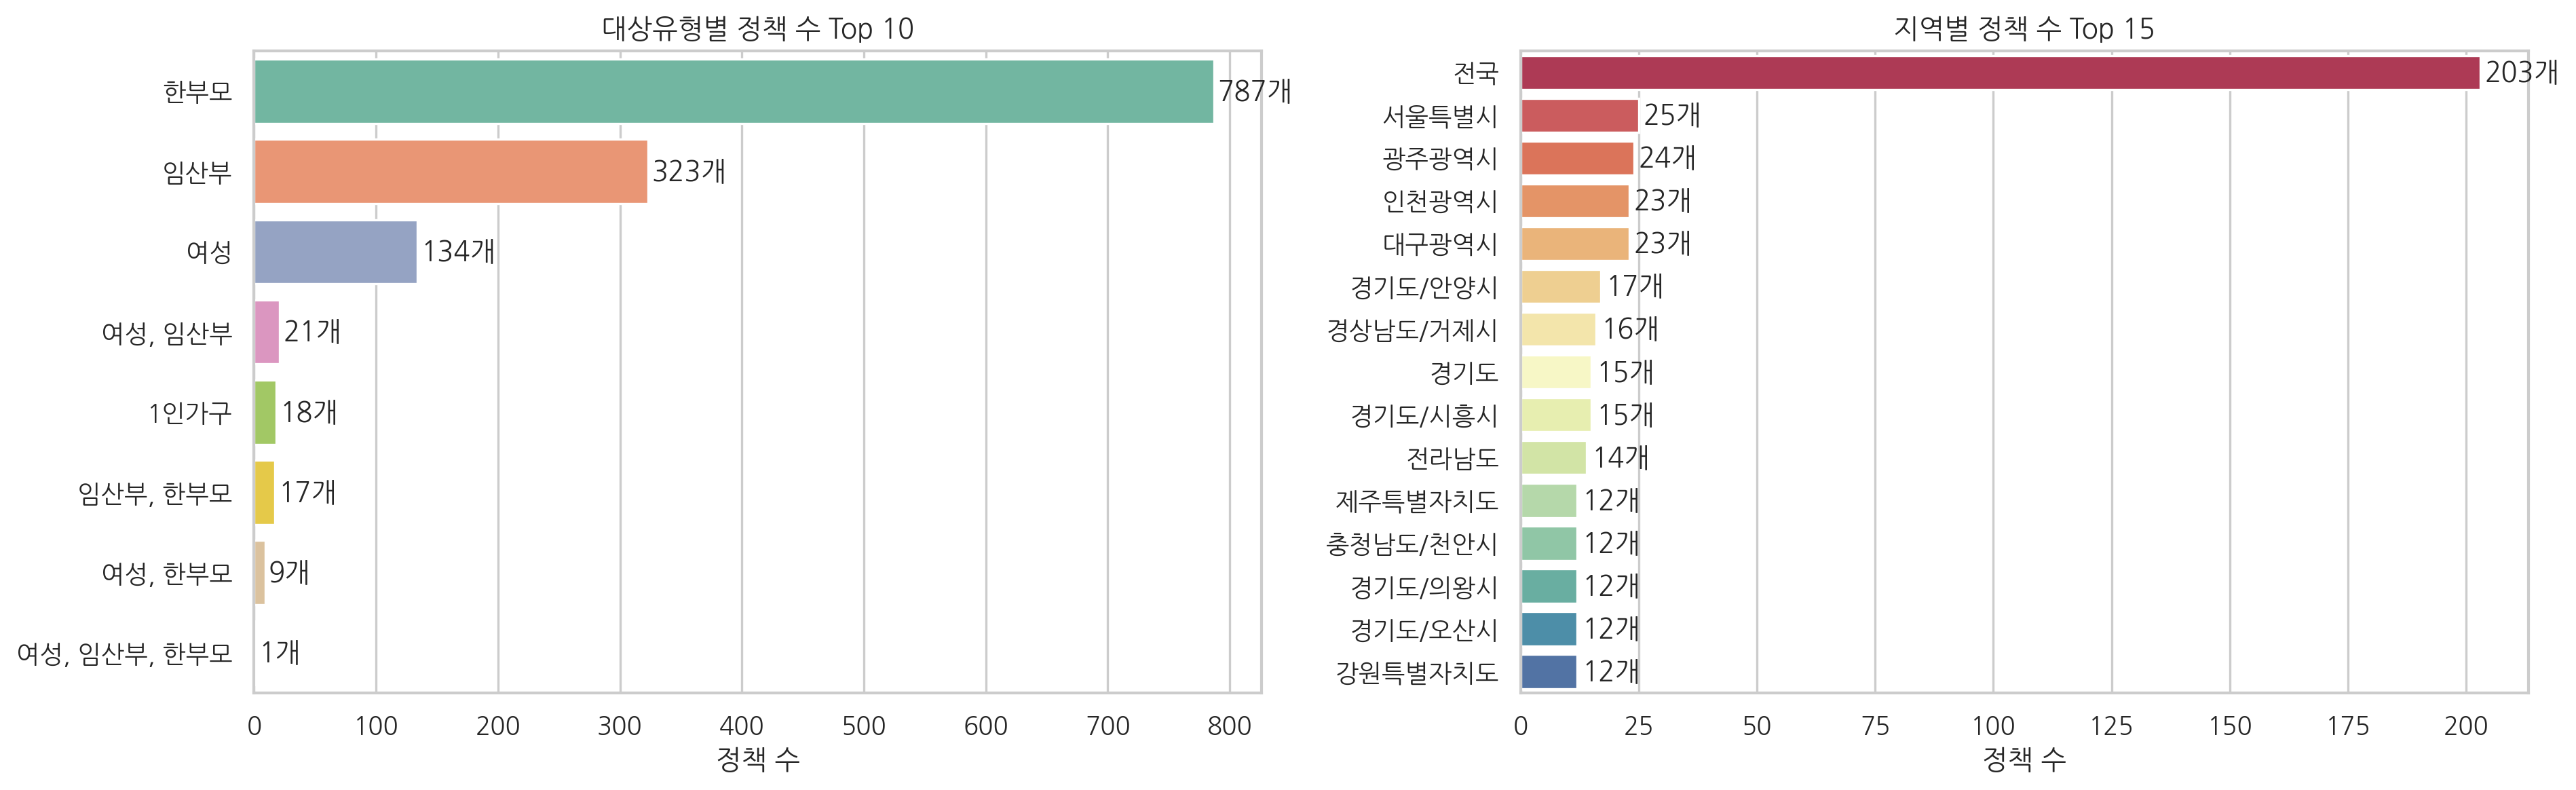

가장 큰 대상유형 '한부모'이 전체의 60.1%를 차지합니다.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
target_counts = df["대상유형"].value_counts().head(10)
sns.barplot(x=target_counts.values, y=target_counts.index, ax=axes[0], palette="Set2")
axes[0].set_title("대상유형별 정책 수 Top 10")
axes[0].set_xlabel("정책 수")
axes[0].set_ylabel("")
for i, v in enumerate(target_counts.values): axes[0].text(v + 3, i, f"{v:,}개", va="center")

region_counts = df["지역"].value_counts().head(15)
sns.barplot(x=region_counts.values, y=region_counts.index, ax=axes[1], palette="Spectral")
axes[1].set_title("지역별 정책 수 Top 15")
axes[1].set_xlabel("정책 수")
axes[1].set_ylabel("")
for i, v in enumerate(region_counts.values): axes[1].text(v + 1, i, f"{v:,}개", va="center")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_target_region_coverage.png", bbox_inches="tight")
plt.show()

major_share = target_counts.iloc[0] / len(df)
print(f"가장 큰 대상유형 '{target_counts.index[0]}'이 전체의 {major_share:.1%}를 차지합니다.")


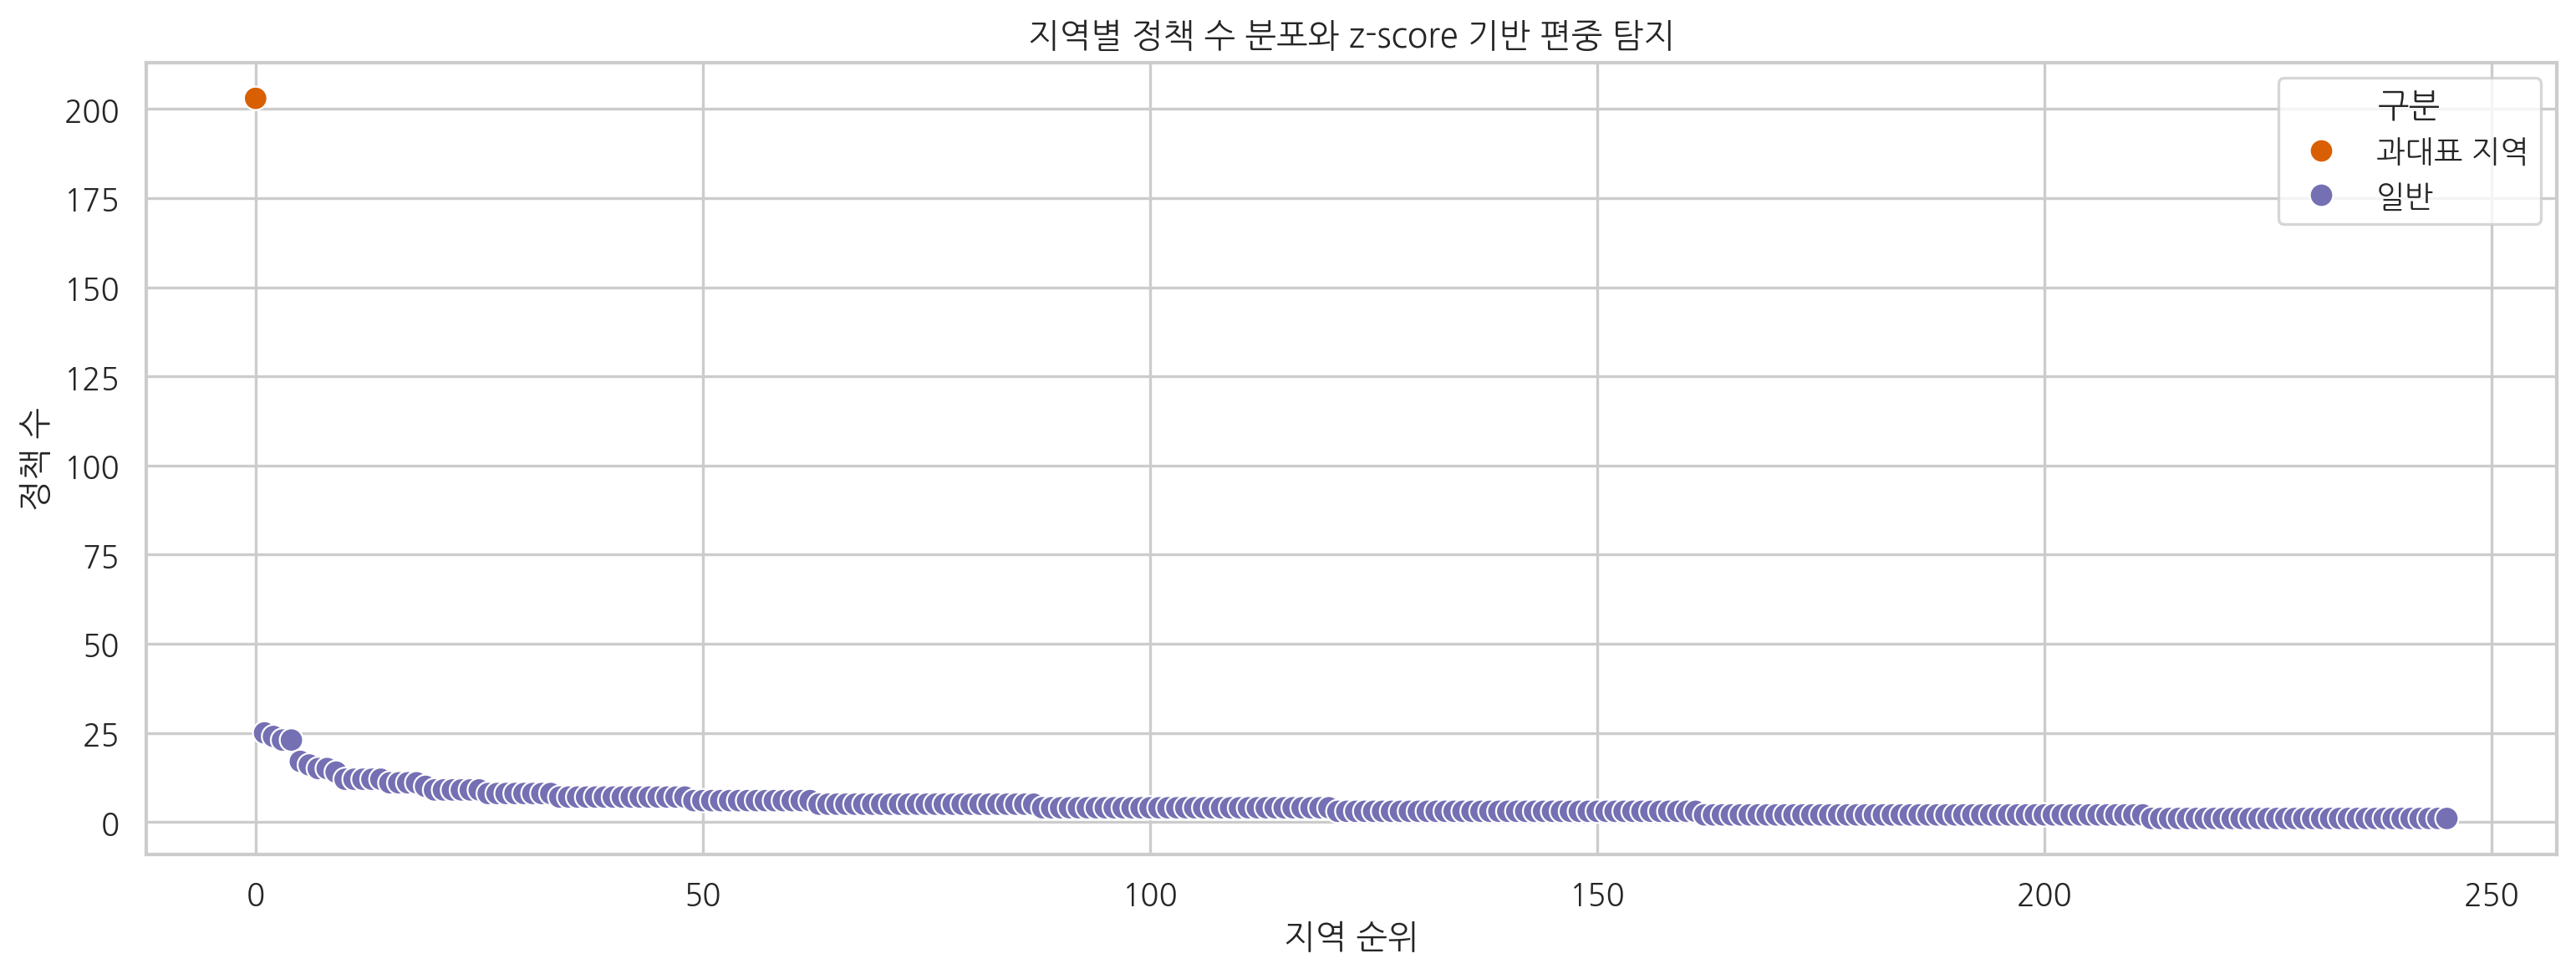

,지역,policy_count,z_score,coverage_group
0,전국,203,14.954976,과대표 지역
1,서울특별시,25,1.488486,일반
2,광주광역시,24,1.412831,일반
3,인천광역시,23,1.337177,일반
4,대구광역시,23,1.337177,일반
5,경기도/안양시,17,0.883250,일반
6,경상남도/거제시,16,0.807596,일반
7,경기도,15,0.731941,일반
8,경기도/시흥시,15,0.731941,일반
9,전라남도,14,0.656287,일반


,지역,policy_count,z_score,coverage_group
0,전국,203,14.954976,과대표 지역


In [5]:
from scipy.stats import zscore
region_df = df["지역"].value_counts().rename_axis("지역").reset_index(name="policy_count")
region_df["z_score"] = zscore(region_df["policy_count"].astype(float))
region_df["coverage_group"] = np.select([region_df["z_score"] >= 2, region_df["z_score"] <= -1], ["과대표 지역", "저커버리지 후보"], default="일반")

plt.figure(figsize=(13, 5))
sns.scatterplot(data=region_df, x=range(len(region_df)), y="policy_count", hue="coverage_group", palette={"과대표 지역":"#d95f02", "저커버리지 후보":"#1b9e77", "일반":"#7570b3"}, s=70)
plt.title("지역별 정책 수 분포와 z-score 기반 편중 탐지")
plt.xlabel("지역 순위")
plt.ylabel("정책 수")
plt.legend(title="구분")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_region_zscore_outliers.png", bbox_inches="tight")
plt.show()
display(region_df.head(10))
display(region_df[region_df["coverage_group"] != "일반"].head(20))


## 3. 지원형태 EDA

지원형태는 사용자의 체감 가치와 바로 연결된다. 직접금전, 감면, 의료, 주거처럼 체감 가치가 큰 정책을 먼저 찾게 만들면 서비스 만족도와 전환율을 높일 수 있다.


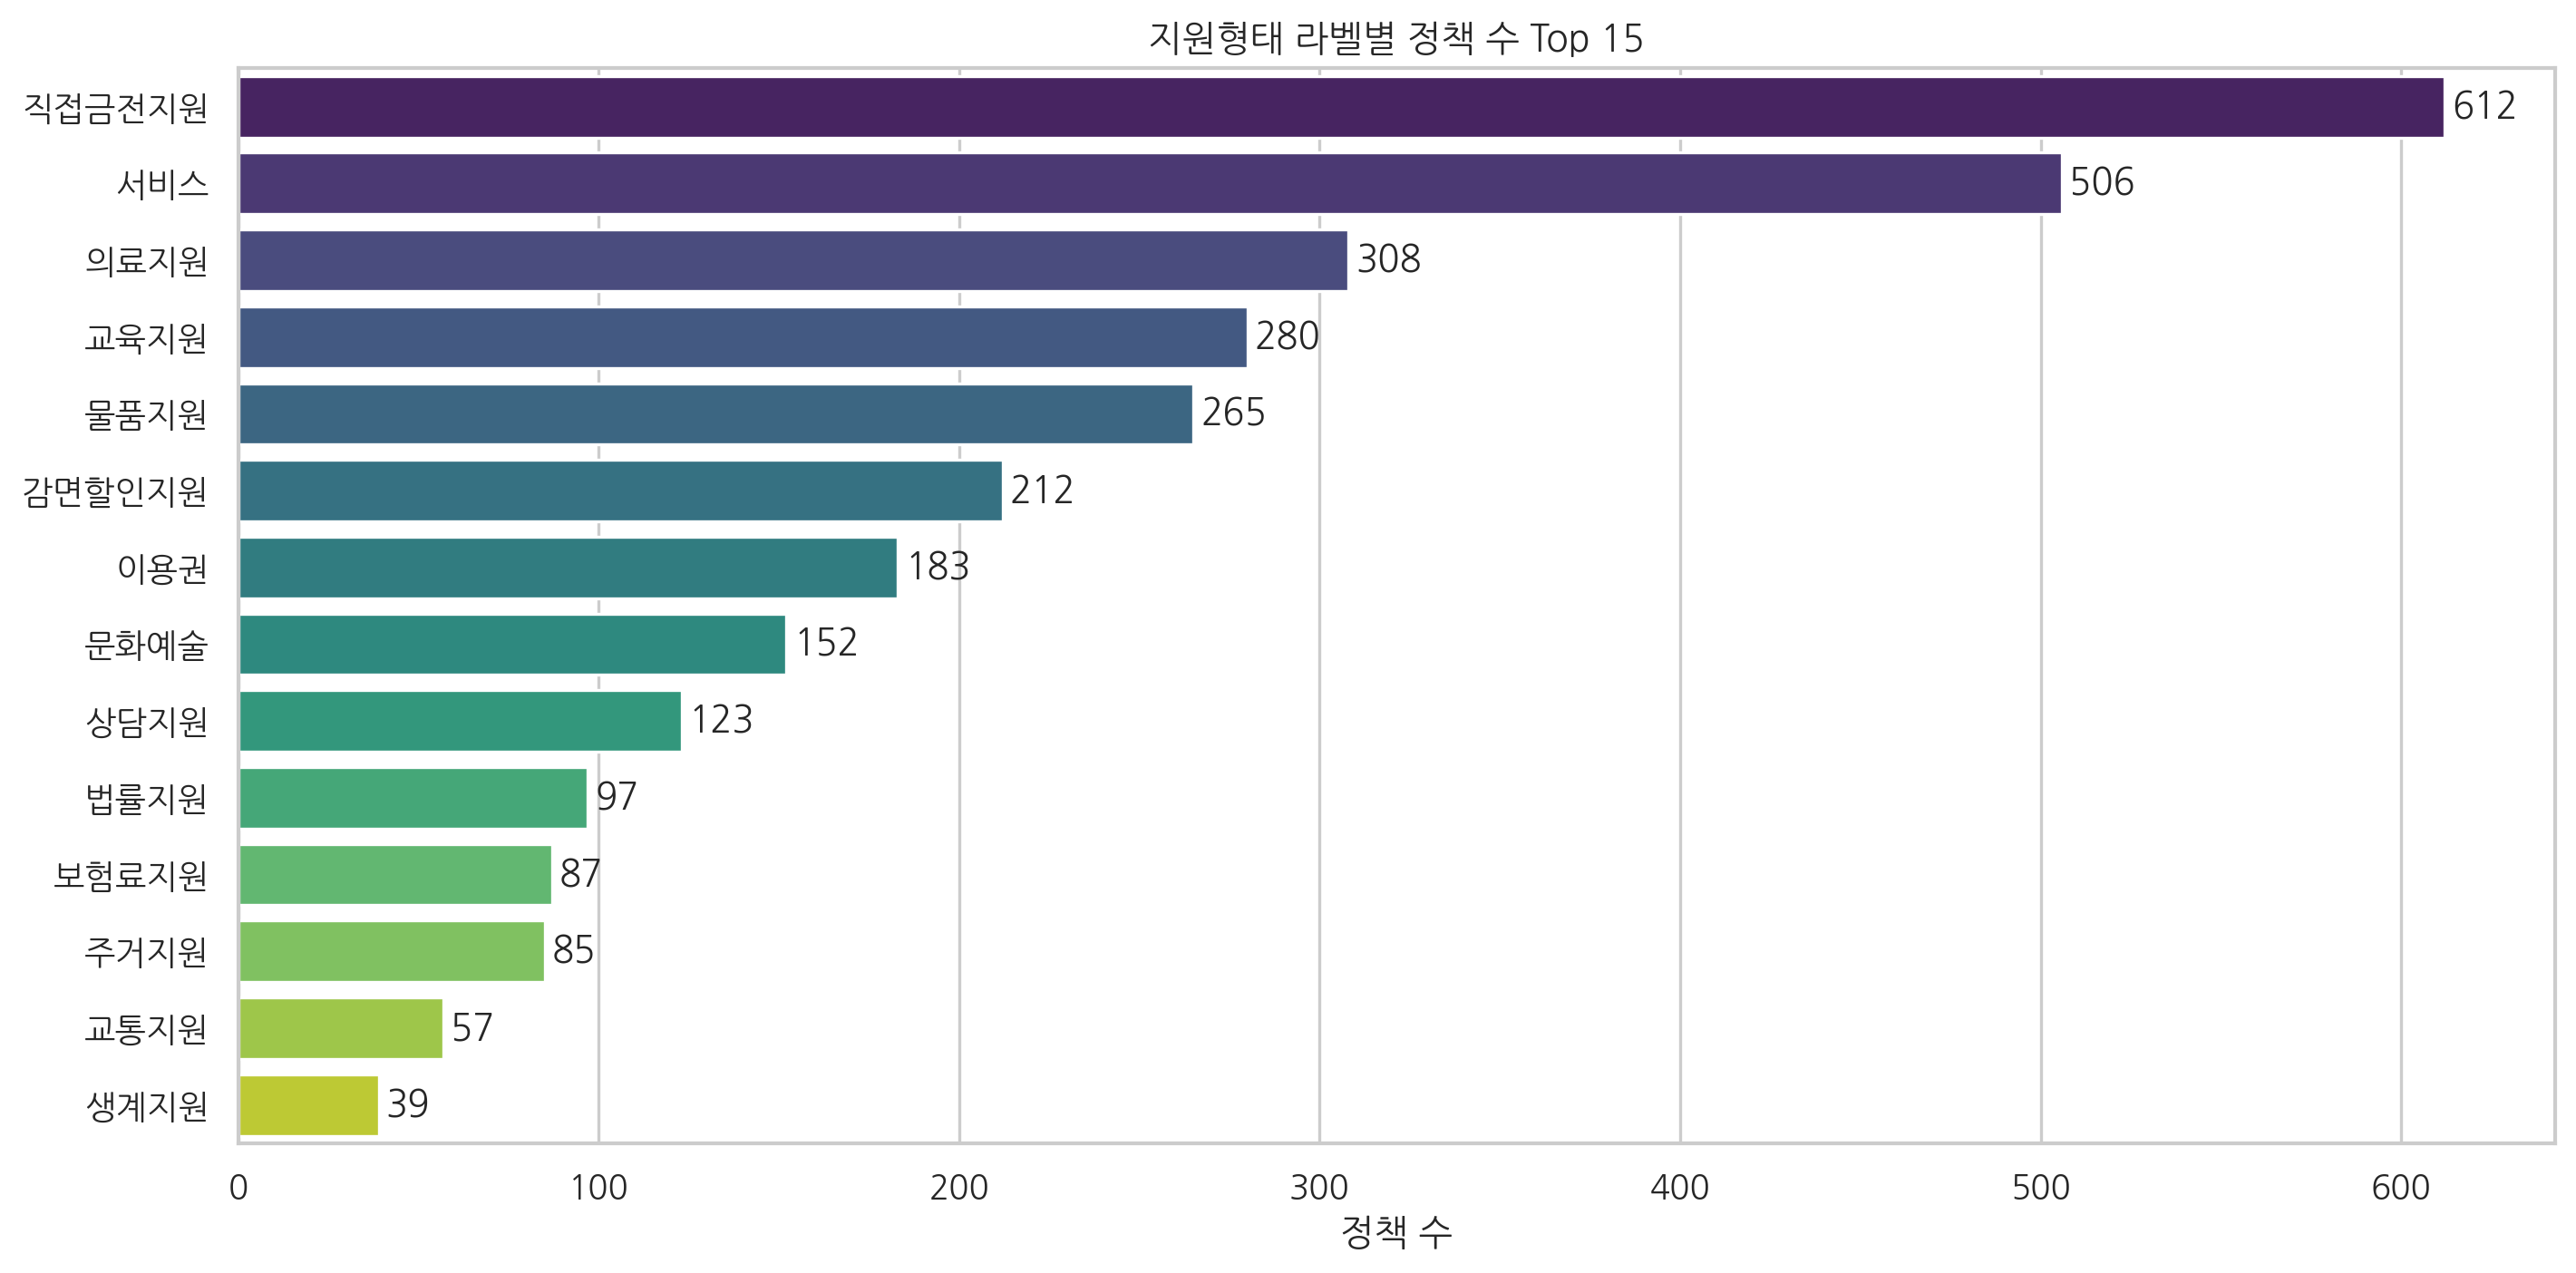

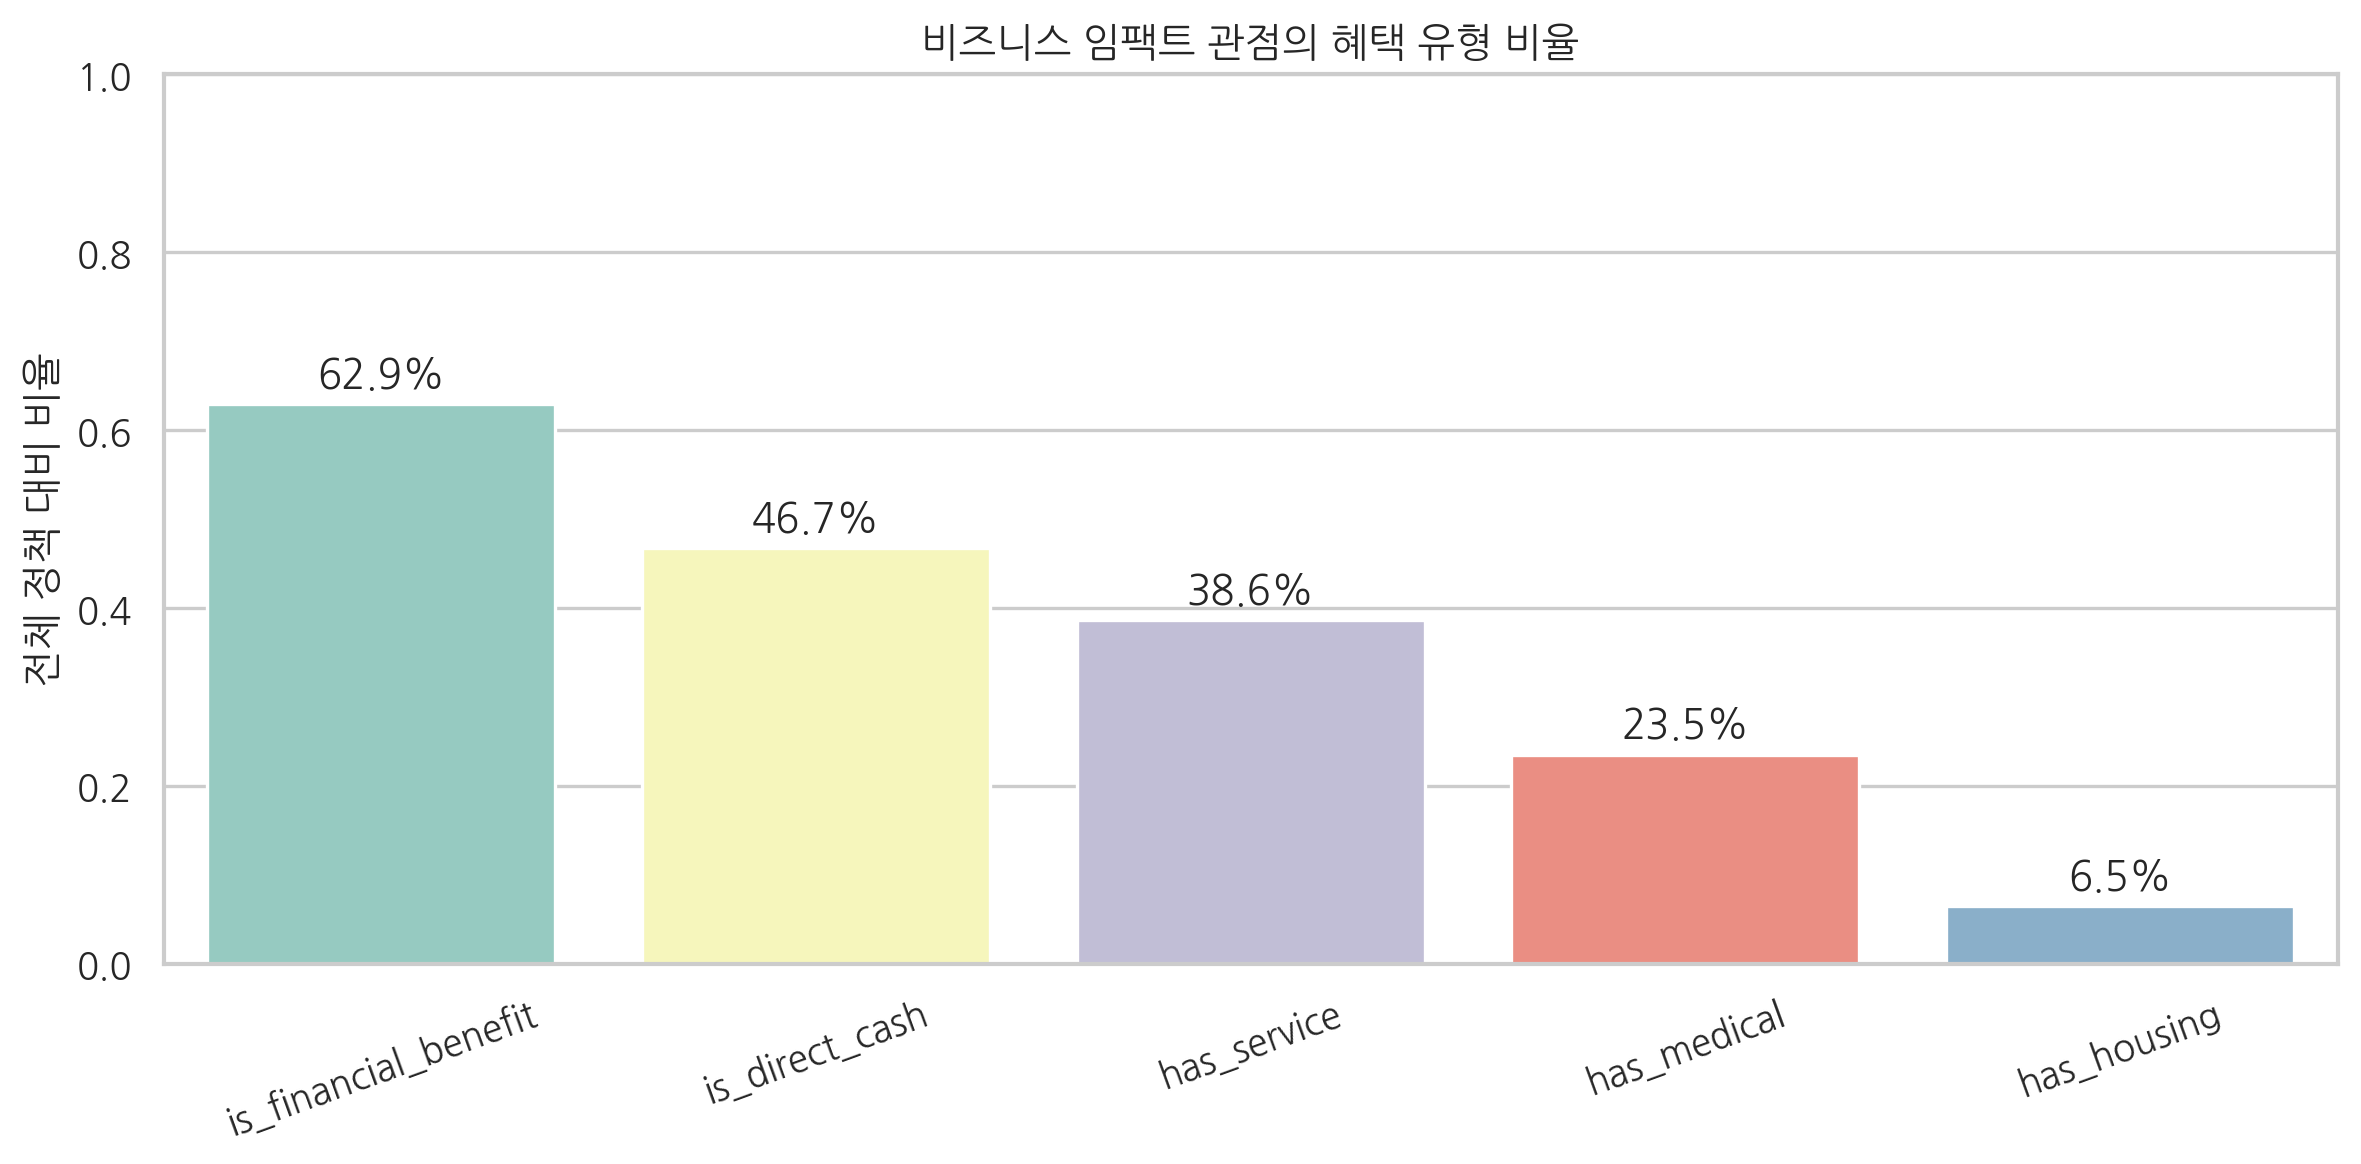

In [6]:
support_exploded = df[["제목", "대상유형", "지역", "지원형태_분류", "support_labels", "is_financial_benefit", "is_direct_cash", "amount_proxy_million"]].explode("support_labels")
support_exploded = support_exploded[support_exploded["support_labels"].notna() & (support_exploded["support_labels"] != "")]
support_counts = support_exploded["support_labels"].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=support_counts.values, y=support_counts.index, palette="viridis")
plt.title("지원형태 라벨별 정책 수 Top 15")
plt.xlabel("정책 수")
plt.ylabel("")
for i, v in enumerate(support_counts.values): plt.text(v + 2, i, f"{v:,}", va="center")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_support_type_counts.png", bbox_inches="tight")
plt.show()

benefit_rate = df[["is_financial_benefit", "is_direct_cash", "has_medical", "has_housing", "has_service"]].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=benefit_rate.index, y=benefit_rate.values, palette="Set3")
plt.title("비즈니스 임팩트 관점의 혜택 유형 비율")
plt.ylabel("전체 정책 대비 비율")
plt.xlabel("")
plt.ylim(0, 1)
for i, v in enumerate(benefit_rate.values): plt.text(i, v + 0.02, f"{v:.1%}", ha="center")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_benefit_rate.png", bbox_inches="tight")
plt.show()


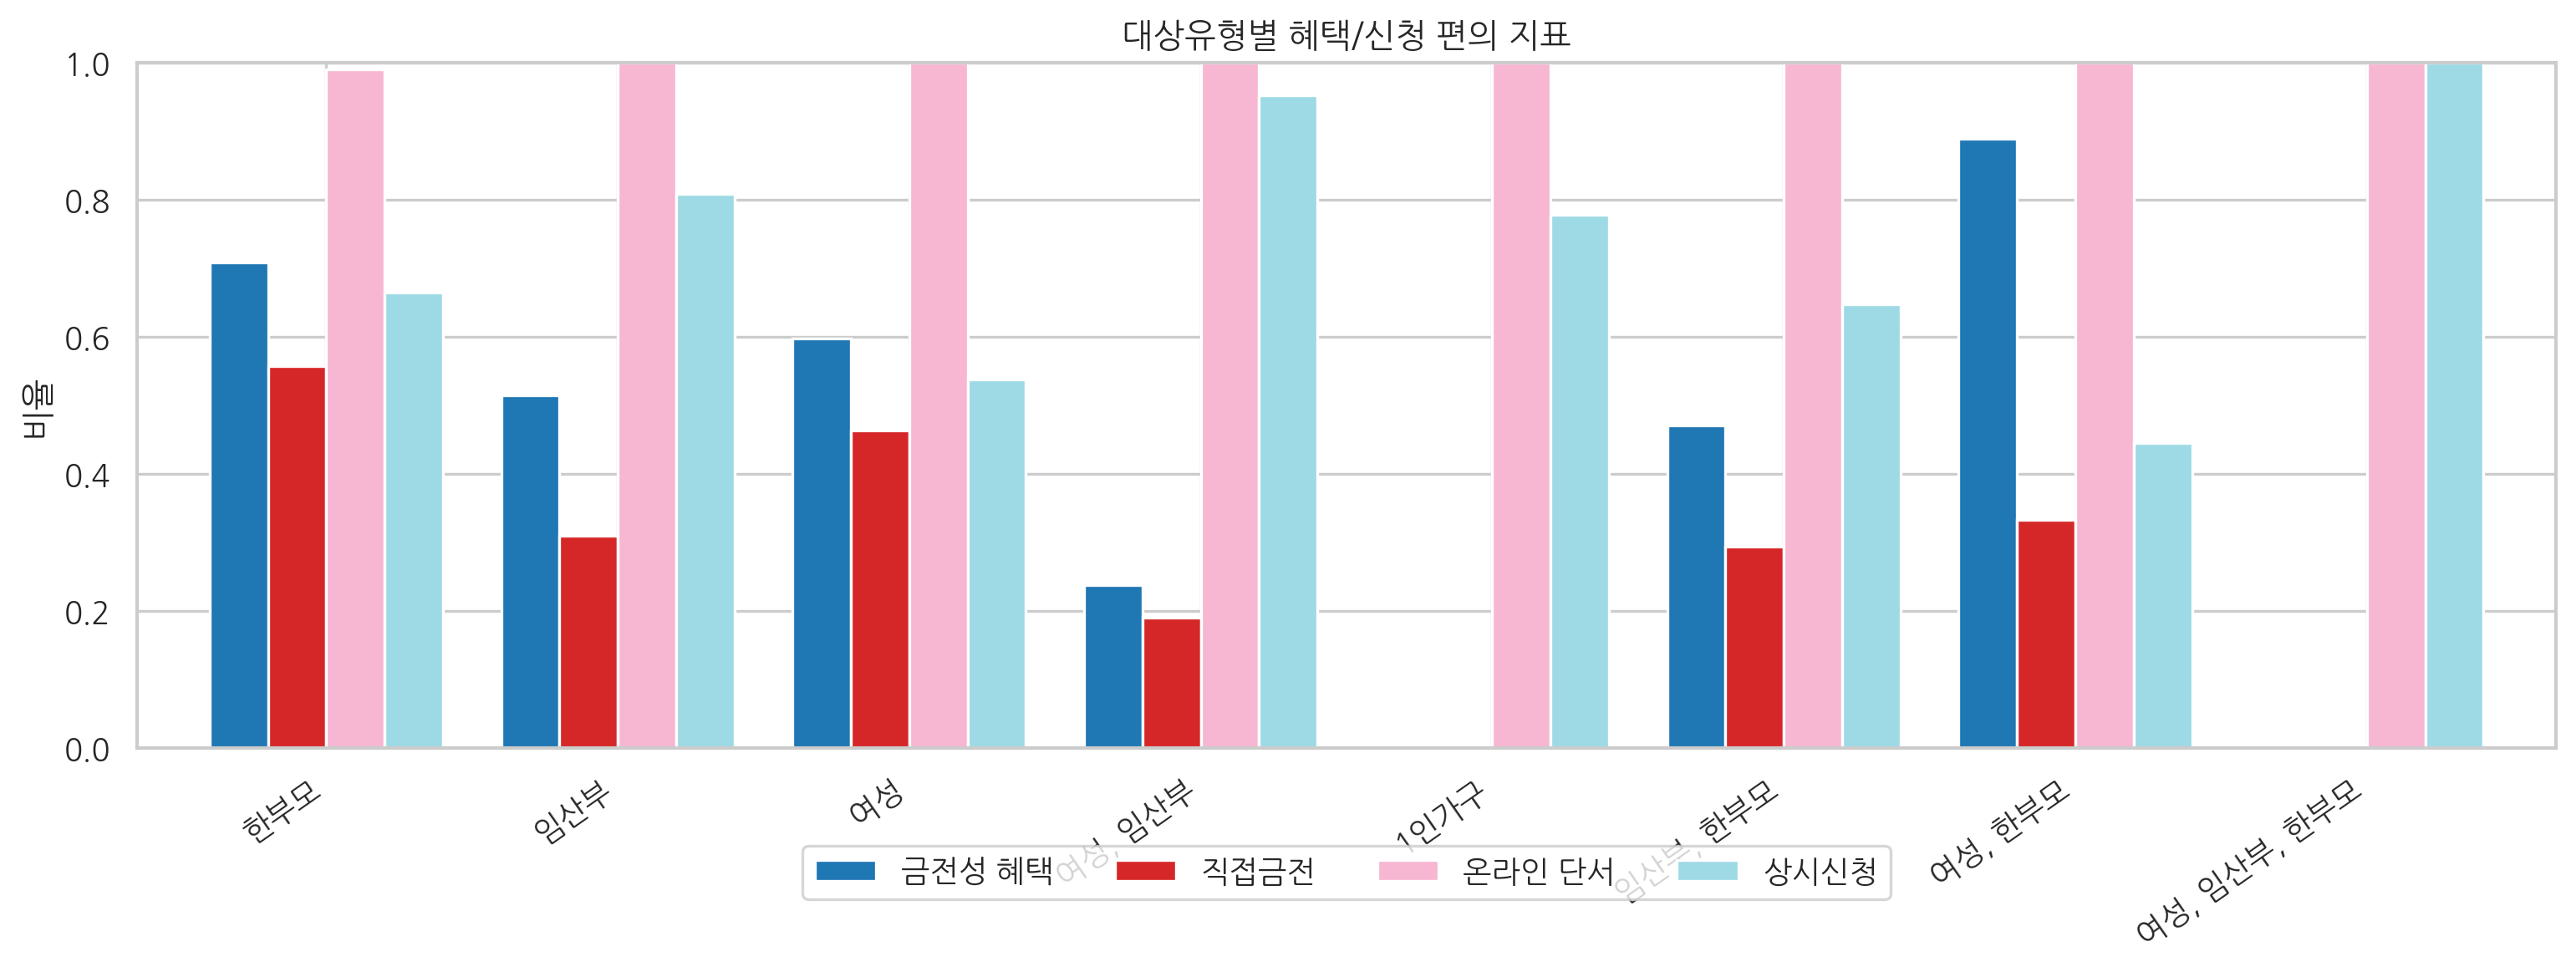

,policy_count,financial_rate,direct_cash_rate,online_rate,always_open_rate
대상유형,,,,,
한부모,787,0.708,0.557,0.99,0.665
임산부,323,0.514,0.310,1.00,0.808
여성,134,0.597,0.463,1.00,0.537
"여성, 임산부",21,0.238,0.190,1.00,0.952
1인가구,18,0.000,0.000,1.00,0.778
"임산부, 한부모",17,0.471,0.294,1.00,0.647
"여성, 한부모",9,0.889,0.333,1.00,0.444
"여성, 임산부, 한부모",1,0.000,0.000,1.00,1.000


In [7]:
money_by_target = df.groupby("대상유형").agg(
    policy_count=("제목", "count"),
    financial_rate=("is_financial_benefit", "mean"),
    direct_cash_rate=("is_direct_cash", "mean"),
    online_rate=("has_online_apply", "mean"),
    always_open_rate=("is_always_open", "mean"),
).sort_values("policy_count", ascending=False).head(12)

fig, ax = plt.subplots(figsize=(13, 5))
money_by_target[["financial_rate", "direct_cash_rate", "online_rate", "always_open_rate"]].plot(kind="bar", ax=ax, width=0.8, colormap="tab20")
ax.set_title("대상유형별 혜택/신청 편의 지표")
ax.set_ylabel("비율")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.legend(["금전성 혜택", "직접금전", "온라인 단서", "상시신청"], ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_target_business_rates.png", bbox_inches="tight")
plt.show()
display(money_by_target.round(3))


## 4. 통계 검정과 금액 프록시

카이제곱 검정은 `대상유형`과 `금전성 혜택 여부`가 독립적인지 확인하기 위해 사용한다. 금액 분포는 오른쪽으로 치우치기 쉬워 카테고리 비교에는 비모수 Kruskal-Wallis 검정을 사용한다.


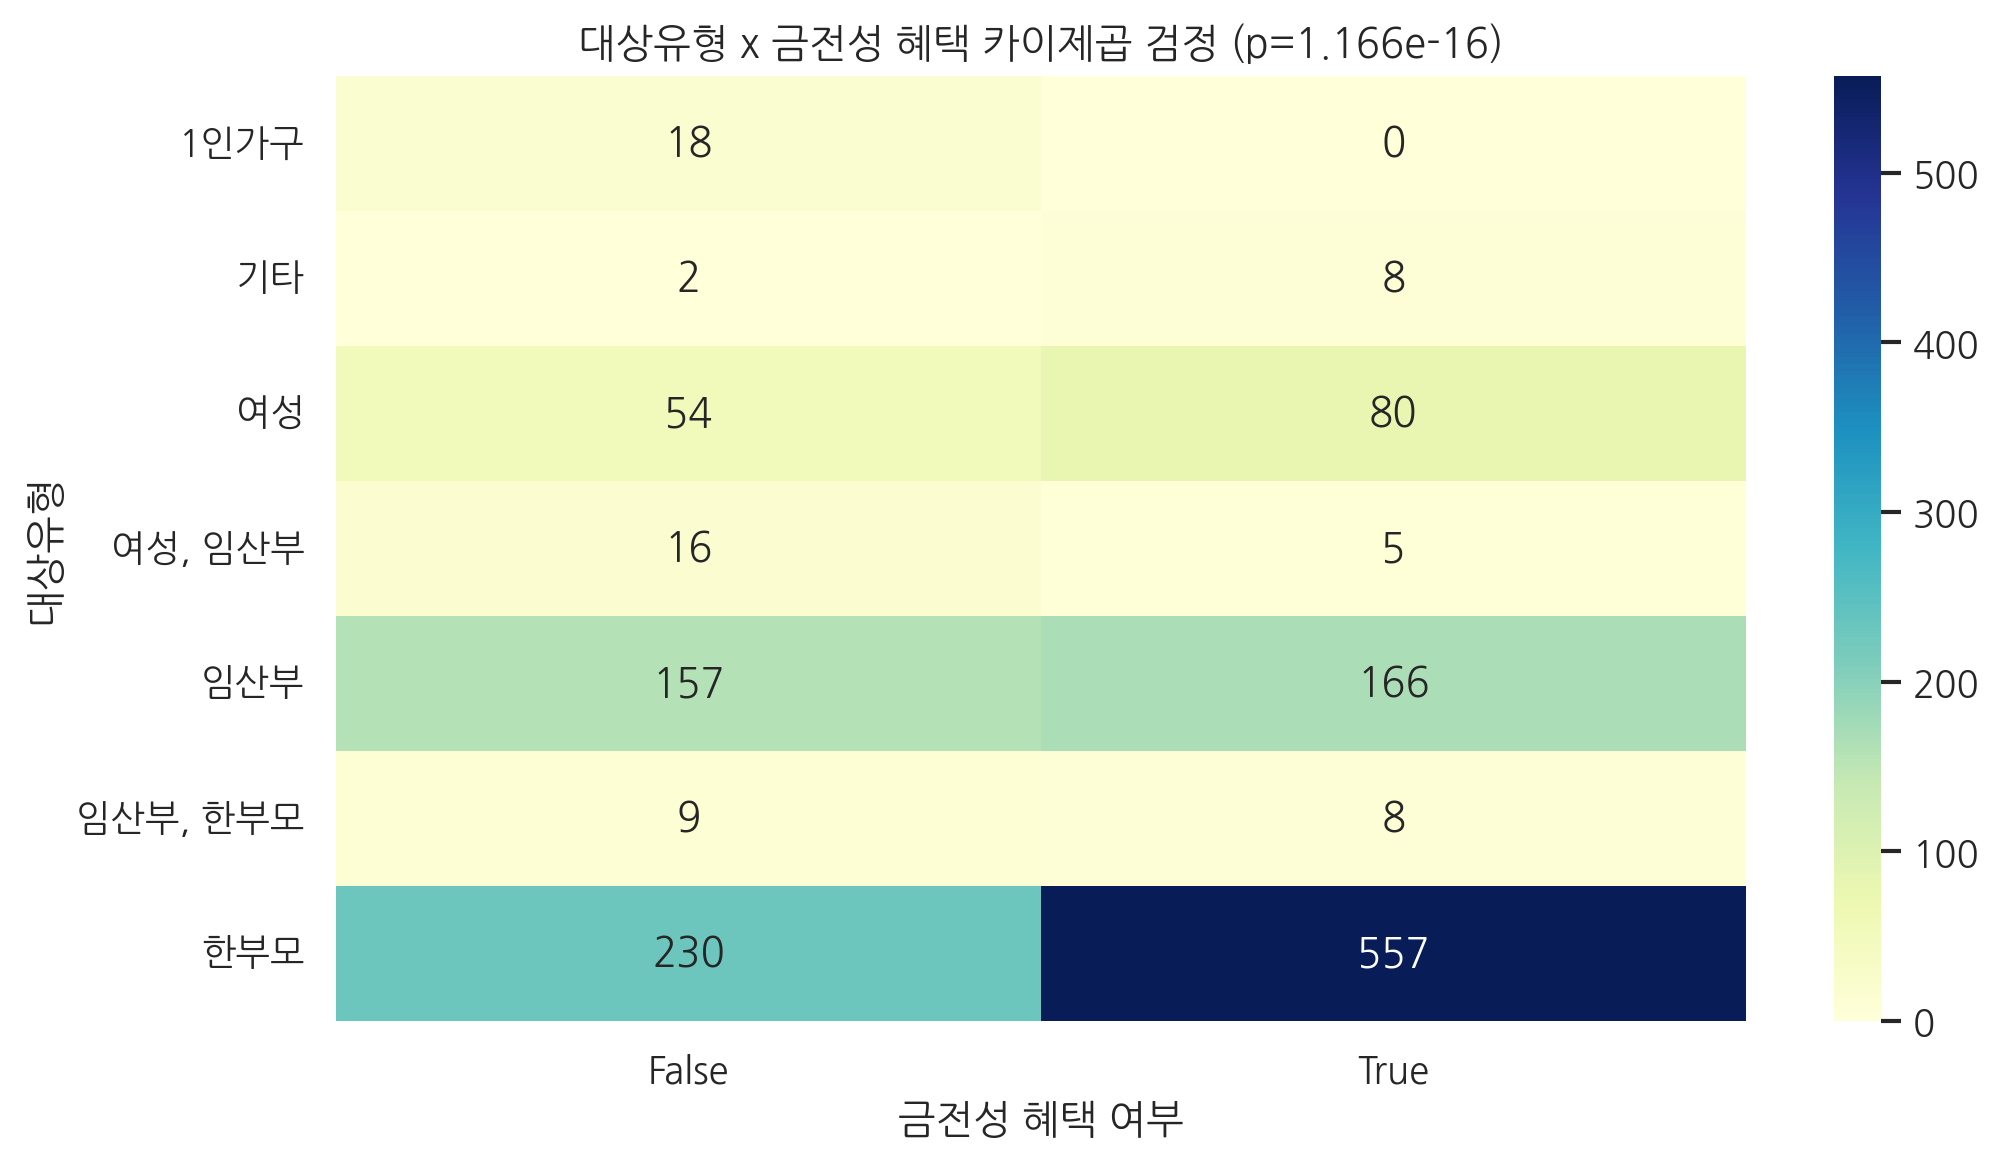

chi2=87.180, dof=6, p-value=0.000000
해석: 대상유형과 금전성 혜택 여부는 독립이라고 보기 어렵습니다.


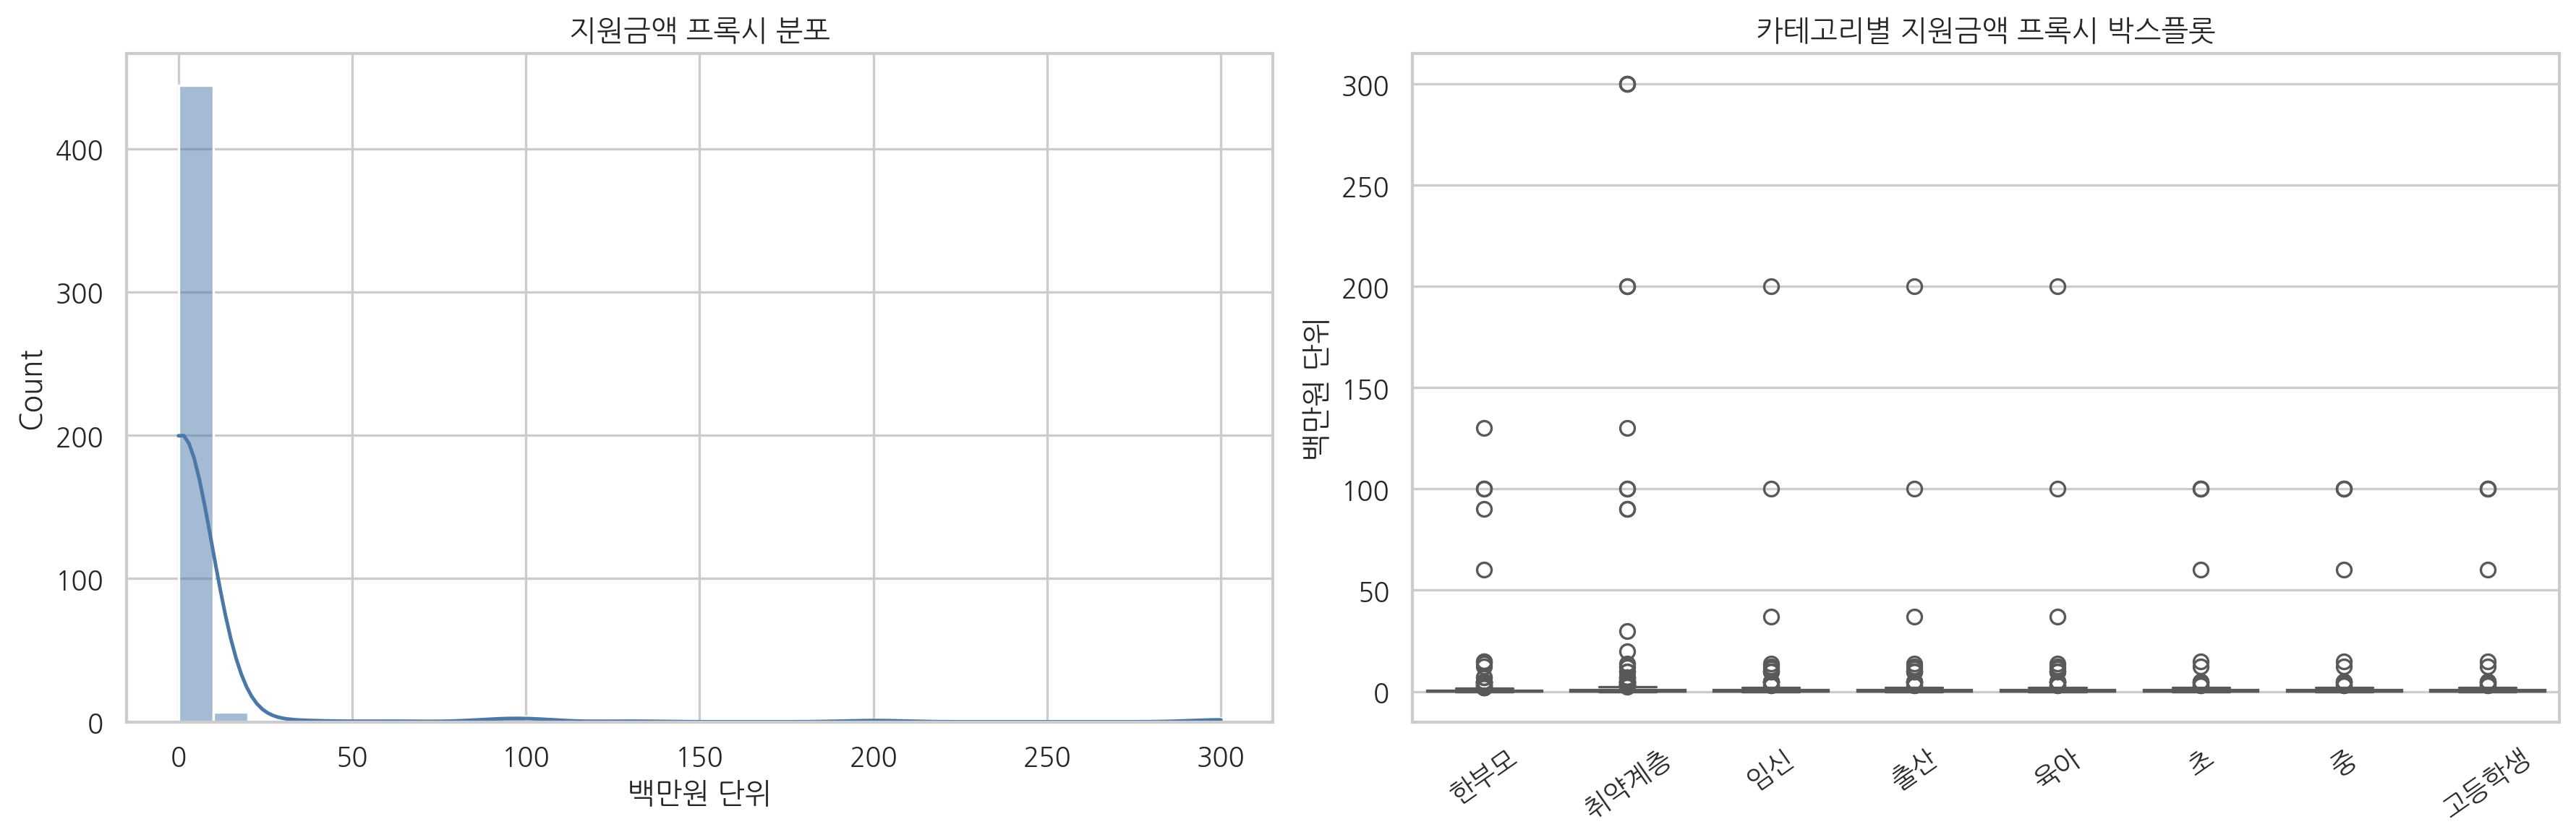

Kruskal-Wallis H=3.297, p-value=0.856186
금액 프록시 추출 정책: 466개 / 전체 1,310개 (35.6%)


In [8]:
from scipy.stats import chi2_contingency, kruskal
top_targets = df["대상유형"].value_counts().head(6).index
stat_df = df.copy()
stat_df["target_group"] = np.where(stat_df["대상유형"].isin(top_targets), stat_df["대상유형"], "기타")
contingency = pd.crosstab(stat_df["target_group"], stat_df["is_financial_benefit"])
chi2, p, dof, expected = chi2_contingency(contingency)

plt.figure(figsize=(9, 5))
sns.heatmap(contingency, annot=True, fmt="d", cmap="YlGnBu")
plt.title(f"대상유형 x 금전성 혜택 카이제곱 검정 (p={p:.4g})")
plt.xlabel("금전성 혜택 여부")
plt.ylabel("대상유형")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_chi_square_heatmap.png", bbox_inches="tight")
plt.show()
print(f"chi2={chi2:.3f}, dof={dof}, p-value={p:.6f}")
print("해석:", "대상유형과 금전성 혜택 여부는 독립이라고 보기 어렵습니다." if p < 0.05 else "통계적으로 뚜렷한 차이는 확인되지 않았습니다.")

amount_df = df[df["amount_proxy_million"].notna()].copy()
amount_df = amount_df[amount_df["amount_proxy_million"] <= amount_df["amount_proxy_million"].quantile(0.99)]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(amount_df["amount_proxy_million"], bins=30, kde=True, ax=axes[0], color="#4c78a8")
axes[0].set_title("지원금액 프록시 분포")
axes[0].set_xlabel("백만원 단위")
cat_amount = amount_df.explode("category_labels")
top_cats = cat_amount["category_labels"].value_counts().head(8).index
cat_amount_top = cat_amount[cat_amount["category_labels"].isin(top_cats)]
sns.boxplot(data=cat_amount_top, x="category_labels", y="amount_proxy_million", ax=axes[1], palette="Set2")
axes[1].set_title("카테고리별 지원금액 프록시 박스플롯")
axes[1].set_xlabel("")
axes[1].set_ylabel("백만원 단위")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_amount_proxy_distribution.png", bbox_inches="tight")
plt.show()
groups = [g["amount_proxy_million"].dropna().values for _, g in cat_amount_top.groupby("category_labels") if len(g) >= 5]
if len(groups) >= 2:
    h, p_kw = kruskal(*groups)
    print(f"Kruskal-Wallis H={h:.3f}, p-value={p_kw:.6f}")
print(f"금액 프록시 추출 정책: {len(amount_df):,}개 / 전체 {len(df):,}개 ({len(amount_df)/len(df):.1%})")


## 5. 검색 구조 개선 실험

정책 추천 서비스의 문제는 정책이 존재하느냐보다, 사용자가 자신의 언어로 검색했을 때 찾을 수 있느냐에 가깝다. 그래서 제목 검색과 요약+분류 검색의 상위 결과 적중률을 비교한다.


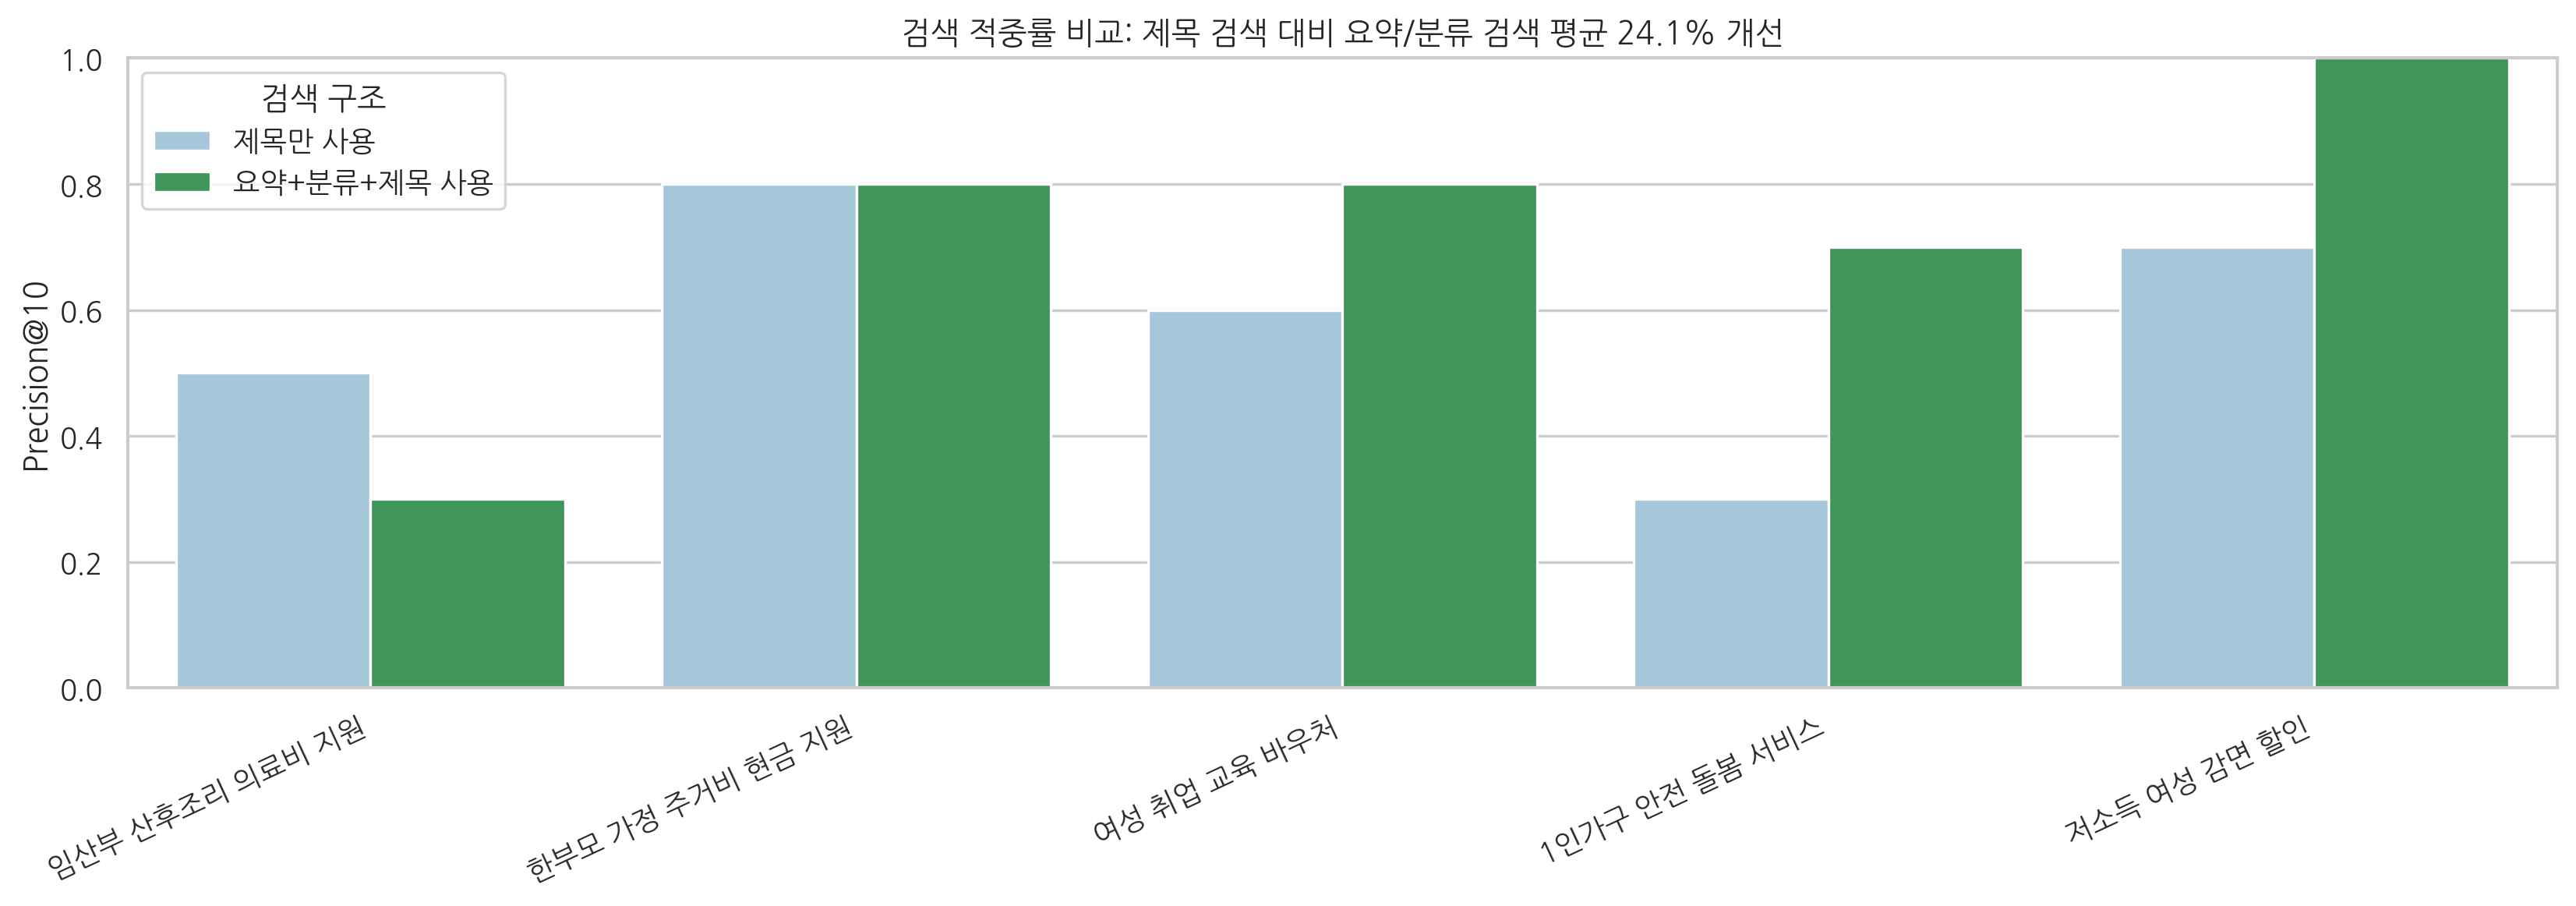

,query,top_k,hit_count,precision_at_k,top_titles,search_type
0,임산부 산후조리 의료비 지원,10,5,0.5,고위험 임산부 의료비 지원 | 고위험 임산부 의료비 지원 | 고위험 임산부 의료비 지원,제목만 사용
1,한부모 가정 주거비 현금 지원,10,8,0.8,저소득 한부모 가정 지원 | 시흥형 주거비(아동 주거비) 지원 | 한부모 가족지원,제목만 사용
2,여성 취업 교육 바우처,10,6,0.6,취업 후 상환 학자금대출 | 여성농업인 바우처 지원 | 여성농업인 바우처 지원,제목만 사용
3,1인가구 안전 돌봄 서비스,10,3,0.3,1인가구 안전도어지킴이 지원사업 | 돌봄 취약가구 반려동물 의료서비스 등 지원 | ...,제목만 사용
4,저소득 여성 감면 할인,10,7,0.7,안동레이크골프장 입장요금 할인(여성) | 보문골프장 입장요금 할인(여성) | 여성 ...,제목만 사용
5,임산부 산후조리 의료비 지원,10,3,0.3,요실금 의료비 지원 | 미혼모 의료비 지원 | 미혼 한부모 자녀 의료비 지원,요약+분류+제목 사용
6,한부모 가정 주거비 현금 지원,10,8,0.8,한부모가족 생신 챙겨드리기 | 한부모가정 가계 지원 | 저소득 한부모 가정 지원,요약+분류+제목 사용
7,여성 취업 교육 바우처,10,8,0.8,여성장애인종합지원사업 운영 지원 | 여성 벤처 활성화 지원 | 여성스포츠리더육성 교육제공,요약+분류+제목 사용
8,1인가구 안전 돌봄 서비스,10,7,0.7,돌봄 취약가구 반려동물 의료서비스 등 지원 | 온가족보듬사업 | 장애아가족 양육 지원,요약+분류+제목 사용
9,저소득 여성 감면 할인,10,10,1.0,기획공연 및 전시 관람료 할인 | 체육시설 이용요금 감면(서재문화체육센터) | SR...,요약+분류+제목 사용


search_type,요약+분류+제목 사용,제목만 사용,상승률
query,,,
1인가구 안전 돌봄 서비스,0.7,0.3,1.333
여성 취업 교육 바우처,0.8,0.6,0.333
임산부 산후조리 의료비 지원,0.3,0.5,-0.400
저소득 여성 감면 할인,1.0,0.7,0.429
한부모 가정 주거비 현금 지원,0.8,0.8,0.000


평균 검색 적중률: 제목만 58.0% -> 요약+분류 72.0%
상대 개선율: 24.1%


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

base_text = df["제목"].fillna("").astype(str)
enriched_text = df["제목"] + " " + df["대상유형"].fillna("").astype(str) + " " + df["카테고리_분류"] + " " + df["지원형태_분류"] + " " + df["지원대상_초벌요약"] + " " + df["지원내용_초벌요약"]
queries = [
    {"query":"임산부 산후조리 의료비 지원", "rules":["임산부", "의료|건강|산후|출산|임신"]},
    {"query":"한부모 가정 주거비 현금 지원", "rules":["한부모", "주거|현금|직접금전|지원금|급여"]},
    {"query":"여성 취업 교육 바우처", "rules":["여성", "교육|취업|일자리|이용권|바우처"]},
    {"query":"1인가구 안전 돌봄 서비스", "rules":["1인가구", "안전|돌봄|서비스"]},
    {"query":"저소득 여성 감면 할인", "rules":["여성|한부모|임산부", "감면|할인|저소득|차상위|기초"]},
]

def search_eval(texts, top_k=10):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1, max_features=5000)
    matrix = vectorizer.fit_transform(texts)
    rows = []
    all_text = enriched_text.fillna("").astype(str)
    for q in queries:
        sims = cosine_similarity(vectorizer.transform([q["query"]]), matrix).ravel()
        idx = np.argsort(sims)[::-1][:top_k]
        relevant = all_text.iloc[idx].apply(lambda x: all(re.search(rule, x) for rule in q["rules"]))
        rows.append({"query": q["query"], "top_k": top_k, "hit_count": int(relevant.sum()), "precision_at_k": float(relevant.mean()), "top_titles": " | ".join(df.iloc[idx]["제목"].head(3).tolist())})
    return pd.DataFrame(rows)

base_eval = search_eval(base_text).assign(search_type="제목만 사용")
enriched_eval = search_eval(enriched_text).assign(search_type="요약+분류+제목 사용")
search_result = pd.concat([base_eval, enriched_eval], ignore_index=True)
pivot = search_result.pivot(index="query", columns="search_type", values="precision_at_k")
pivot["상승률"] = (pivot["요약+분류+제목 사용"] - pivot["제목만 사용"]) / pivot["제목만 사용"].replace(0, np.nan)
overall_lift = (enriched_eval["precision_at_k"].mean() - base_eval["precision_at_k"].mean()) / max(base_eval["precision_at_k"].mean(), 1e-9)

plt.figure(figsize=(14, 5))
sns.barplot(data=search_result, x="query", y="precision_at_k", hue="search_type", palette=["#9ecae1", "#31a354"])
plt.title(f"검색 적중률 비교: 제목 검색 대비 요약/분류 검색 평균 {overall_lift:.1%} 개선")
plt.ylabel("Precision@10")
plt.xlabel("")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.legend(title="검색 구조")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "08_search_precision_lift.png", bbox_inches="tight")
plt.show()
display(search_result)
display(pivot.round(3))
print(f"평균 검색 적중률: 제목만 {base_eval['precision_at_k'].mean():.1%} -> 요약+분류 {enriched_eval['precision_at_k'].mean():.1%}")
print(f"상대 개선율: {overall_lift:.1%}")


## 6. 원본 모델링 파이프라인 정리: 1차 Clean_text + 2차 Gemma 요약

이 프로젝트의 모델링 흐름은 실제 기존 노트북 기준으로 2단계다.

- 1차: `match/Clean_text.ipynb`에서 `지원대상`, `지원내용` 원문을 정제하고, 반복 문구를 줄인 뒤 `EbanLee/kobart-summary-v3`로 `지원대상_초벌요약`, `지원내용_초벌요약`을 만든다.
- 1차 산출물: `여성맞춤정책_요약_2차_결과.xlsx` 계열의 중간 엑셀로 저장한다.
- 2차: `match/Summarize_Excel_with_Gemma_2_and_Drafts_(Colab_Auto_Find).ipynb`에서 LangChain/LangGraph 기반 배치 추론으로 Gemma/Qwen 요약을 수행하고 CSV 스트리밍 저장 및 재시작이 가능하게 구성한다.
- 2차 요약 LLM: `google/gemma-2-9b-it`를 기본 모델로 사용하고, 접근 또는 로딩 실패 시 `Qwen/Qwen2.5-7B-Instruct`로 자동 폴백한다.
- 2차 양자화: GPU와 bitsandbytes가 있으면 4-bit NF4 + bfloat16으로 로딩하고, 없으면 bf16 또는 float32로 일반 로딩한다.
- 2차 추론 설정: `BATCH_SIZE=4`, `MAX_NEW_TOKENS=300`, 기본 `DO_SAMPLE=False`로 결정적 greedy 생성을 사용한다. `DO_SAMPLE=True`일 때만 temperature 0.3, top_p 0.9를 적용한다.
- 선택 분류 모델: `label` 컬럼이 있는 경우에만 `klue/roberta-base`를 시퀀스 분류용으로 학습해 accuracy, f1, ROC-AUC, NDCG 등을 계산한다.

이 구조를 쓴 이유는 비즈니스적으로 명확하다. 먼저 1차 KoBART 요약으로 긴 정책 원문을 일정한 형식의 초벌요약으로 만들고, 2차 Gemma/Qwen 요약으로 핵심 조건과 혜택을 더 검색 친화적인 문장으로 정리한다. 그 결과가 검색 적중률과 운영 검수 효율을 높이는지는 뒤에서 EDA와 모델 지표로 검증한다.


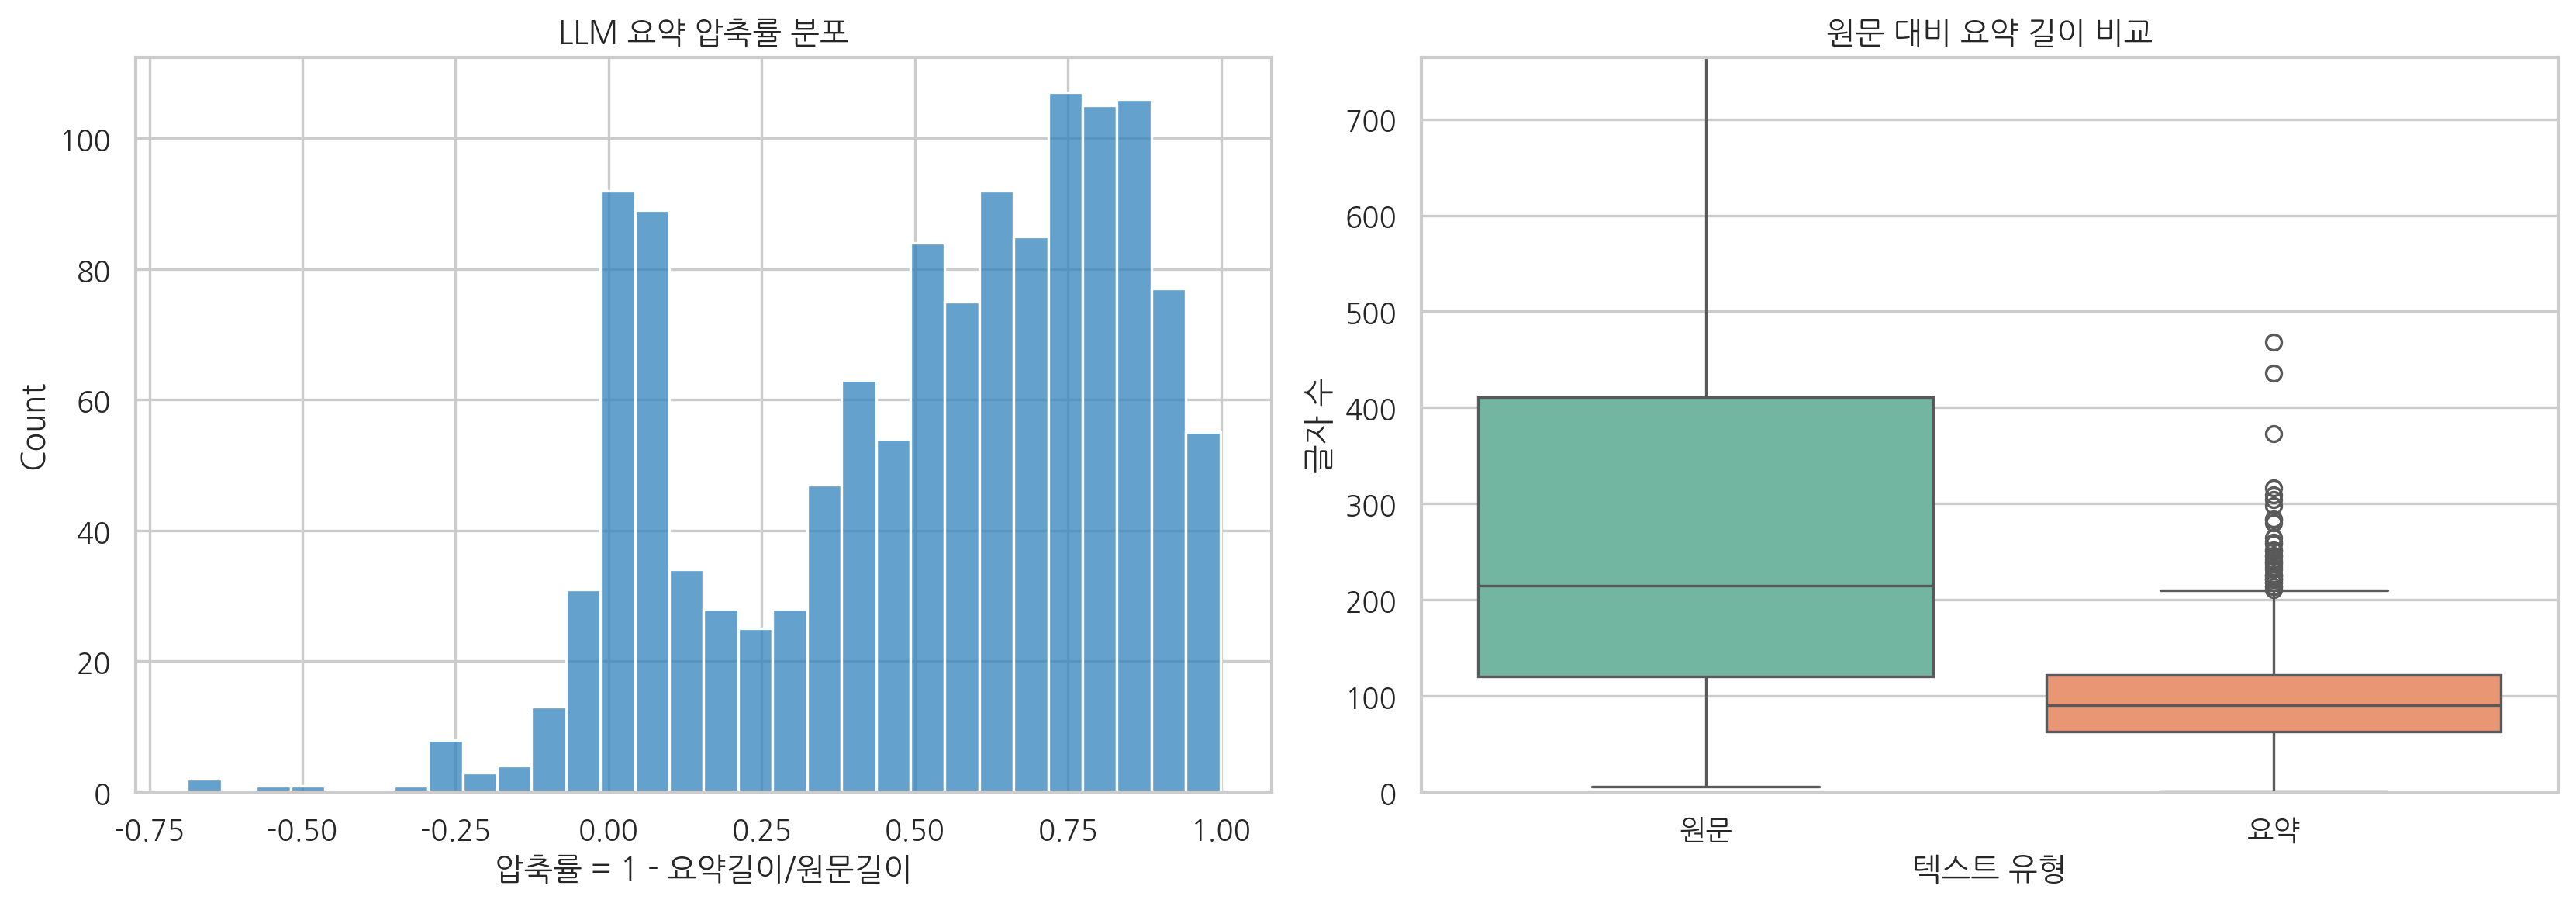

,value
stage_1_notebook,match/Clean_text.ipynb
stage_1_role,"정책 원문 정제, 반복 문구 축소, KoBART 초벌요약 생성"
stage_1_model,EbanLee/kobart-summary-v3
stage_1_outputs,"지원대상_초벌요약, 지원내용_초벌요약, 여성맞춤정책_요약_2차_결과.xlsx 계열"
stage_2_notebook,match/Summarize_Excel_with_Gemma_2_and_Drafts_...
stage_2_role,"LangChain/LangGraph 기반 2차 배치 요약, CSV 스트리밍 저장, ..."
stage_2_primary_summary_model,google/gemma-2-9b-it
stage_2_fallback_summary_model,Qwen/Qwen2.5-7B-Instruct
stage_2_quantization_policy,"GPU + bitsandbytes 가능 시 4-bit NF4 + bfloat16, ..."
batch_size,4


,value
지원대상 요약 존재 비율,0.978626
지원내용 요약 존재 비율,0.978626
원문 평균 길이,346.307634
요약 평균 길이,96.860305
평균 압축률,0.513707
label 컬럼 존재 여부,False


현재 데이터에는 label 컬럼이 없어 KLUE/RoBERTa 파인튜닝은 실행하지 않고, 뒤 셀에서 금전성 혜택 여부를 비즈니스 라벨로 만든 대체 검증 모델을 사용합니다.


In [10]:
# 기존 1차/2차 노트북 기준 모델 파이프라인 설정 기록 및 요약 산출물 품질 점검
MODEL_PIPELINE_CONFIG = {
    "stage_1_notebook": "match/Clean_text.ipynb",
    "stage_1_role": "정책 원문 정제, 반복 문구 축소, KoBART 초벌요약 생성",
    "stage_1_model": "EbanLee/kobart-summary-v3",
    "stage_1_outputs": "지원대상_초벌요약, 지원내용_초벌요약, 여성맞춤정책_요약_2차_결과.xlsx 계열",
    "stage_2_notebook": "match/Summarize_Excel_with_Gemma_2_and_Drafts_(Colab_Auto_Find).ipynb",
    "stage_2_role": "LangChain/LangGraph 기반 2차 배치 요약, CSV 스트리밍 저장, 재시작 가능 구조",
    "stage_2_primary_summary_model": "google/gemma-2-9b-it",
    "stage_2_fallback_summary_model": "Qwen/Qwen2.5-7B-Instruct",
    "stage_2_quantization_policy": "GPU + bitsandbytes 가능 시 4-bit NF4 + bfloat16, 불가 시 bf16/float32",
    "batch_size": int(os.getenv("BATCH_SIZE", 4)),
    "max_new_tokens": int(os.getenv("MAX_NEW_TOKENS", 300)),
    "do_sample": os.getenv("DO_SAMPLE", "False").lower() == "true",
    "temperature_when_sampling": 0.3,
    "top_p_when_sampling": 0.9,
    "optional_classifier": "label 컬럼이 있을 때만 klue/roberta-base 학습 및 accuracy/f1/ROC-AUC/NDCG 계산",
}

summary_quality = pd.Series({
    "지원대상 요약 존재 비율": (df["지원대상_초벌요약"].str.len() > 0).mean(),
    "지원내용 요약 존재 비율": (df["지원내용_초벌요약"].str.len() > 0).mean(),
    "원문 평균 길이": df["raw_text_len"].mean(),
    "요약 평균 길이": df["summary_len"].mean(),
    "평균 압축률": df["summary_compression_rate"].replace([np.inf, -np.inf], np.nan).mean(),
    "label 컬럼 존재 여부": "label" in df.columns,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["summary_compression_rate"].replace([np.inf, -np.inf], np.nan).dropna(), bins=30, ax=axes[0], color="#3182bd")
axes[0].set_title("LLM 요약 압축률 분포")
axes[0].set_xlabel("압축률 = 1 - 요약길이/원문길이")
length_df = pd.DataFrame({"원문": df["raw_text_len"], "요약": df["summary_len"]}).melt(var_name="텍스트 유형", value_name="글자 수")
sns.boxplot(data=length_df, x="텍스트 유형", y="글자 수", ax=axes[1], palette="Set2")
axes[1].set_title("원문 대비 요약 길이 비교")
axes[1].set_ylim(0, length_df["글자 수"].quantile(0.95))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "11_llm_summary_quality.png", bbox_inches="tight")
plt.show()

model_summary = pd.DataFrame([MODEL_PIPELINE_CONFIG]).T.rename(columns={0: "value"})
quality_summary = summary_quality.to_frame("value")
display(model_summary)
display(quality_summary)

pd.concat([model_summary, quality_summary]).to_csv(OUTPUT_DIR / "model_pipeline_summary.csv", encoding="utf-8-sig")
with open(OUTPUT_DIR / "model_pipeline_summary.txt", "w", encoding="utf-8") as f:
    f.write("[기존 1차/2차 모델 파이프라인 설정]\n")
    for k, v in MODEL_PIPELINE_CONFIG.items():
        f.write(f"- {k}: {v}\n")
    f.write("\n[요약 산출물 품질]\n")
    for k, v in summary_quality.items():
        f.write(f"- {k}: {v}\n")

if "label" in df.columns:
    print("label 컬럼이 있으므로 klue/roberta-base 파인튜닝 평가를 추가할 수 있습니다.")
else:
    print("현재 데이터에는 label 컬럼이 없어 KLUE/RoBERTa 파인튜닝은 실행하지 않고, 뒤 셀에서 금전성 혜택 여부를 비즈니스 라벨로 만든 대체 검증 모델을 사용합니다.")


## 7. 대체 검증 모델: 왜 모델을 쓰는가?

현재 데이터에는 `label` 컬럼이 없으므로 KLUE/RoBERTa 파인튜닝은 실행하지 않는다. 대신 비즈니스 관점에서 중요한 `금전성 혜택 여부`를 규칙 기반 라벨로 만들고, 텍스트와 메타데이터만 보고 **금전성 혜택 정책을 자동으로 선별할 수 있는지** 검증한다.

- 모델: TF-IDF + Logistic Regression
- 선택 이유: 데이터가 크지 않고, 빠르며, 해석 가능하고, 교차검증이 쉽다.
- 검증 방식: Stratified 5-Fold 교차검증
- 비즈니스 해석: 금전성 정책 후보를 먼저 리뷰하면 운영자가 고가치 정책을 더 빨리 검수할 수 있다.


,5-fold CV score
accuracy,0.772
precision,0.826
recall,0.807
f1,0.816
roc_auc,0.845


              precision    recall  f1-score   support

        비금전성       0.69      0.71      0.70       486
         금전성       0.83      0.81      0.82       824

    accuracy                           0.77      1310
   macro avg       0.76      0.76      0.76      1310
weighted avg       0.77      0.77      0.77      1310



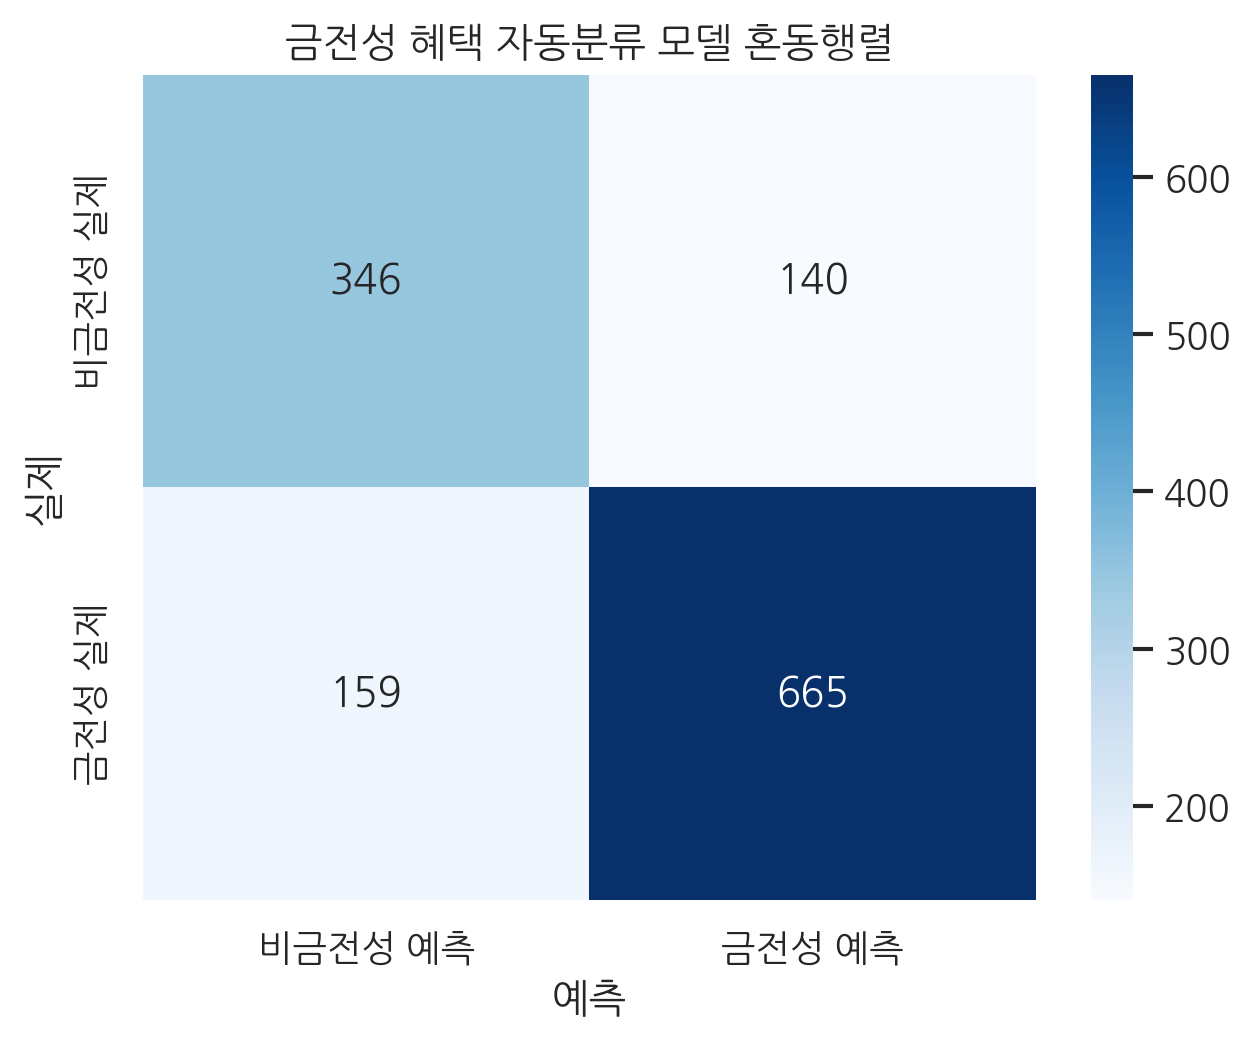

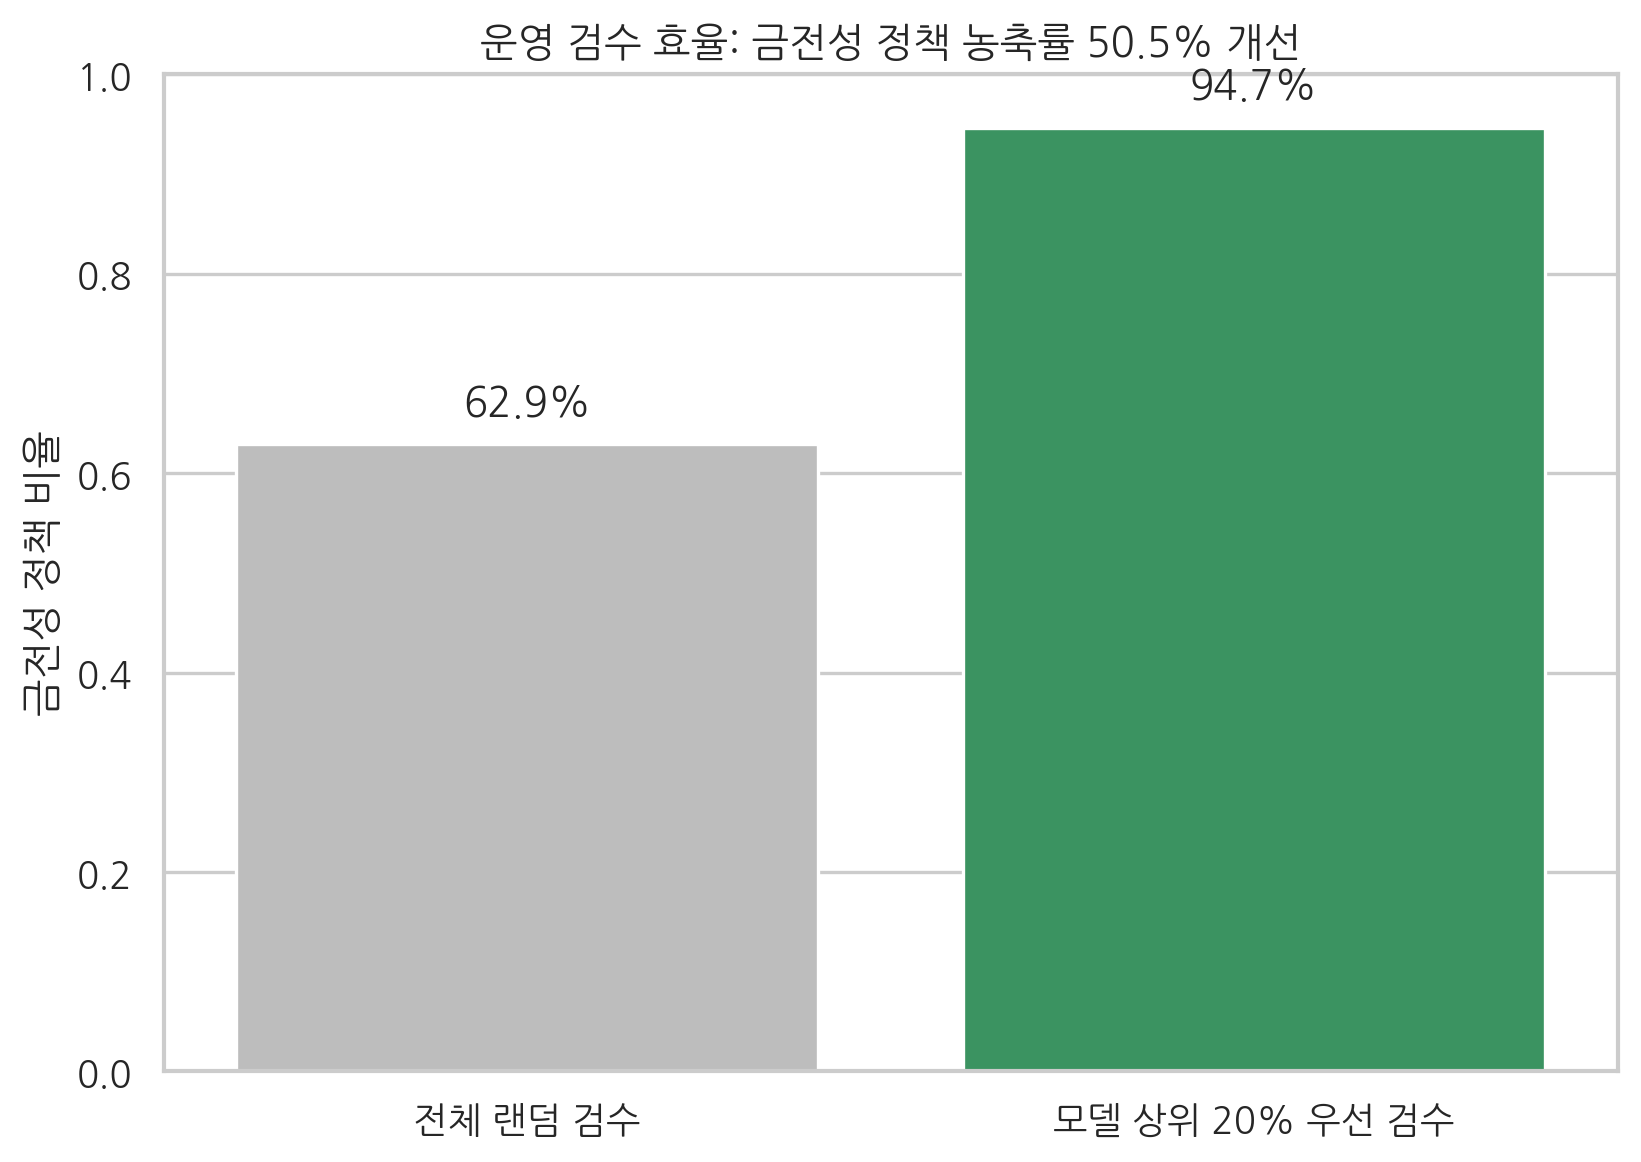

전체 금전성 정책 비율: 62.9%
모델 상위 20% 우선 검수 시 금전성 정책 비율: 94.7%
상대 개선율: 50.5%


,제목,대상유형,지역,지원형태_분류,is_financial_benefit,predicted_financial_prob,top_20pct_review
655,생활체육 및 문화예술아카데미 요금 감면,한부모,서울특별시/마포구,"직접금전지원,감면할인지원,문화예술,법률지원",True,0.965771,True
670,체육시설 이용요금 감면,한부모,서울특별시/성동구,"직접금전지원,감면할인지원,교육지원,문화예술",True,0.950129,True
805,체육시설 이용요금 감면,한부모,인천광역시/서구,"직접금전지원,감면할인지원,교육지원,문화예술,서비스,법률지원",True,0.948900,True
473,체육시설 이용요금 감면(서재문화체육센터),한부모,대구광역시,"감면할인지원,문화예술,서비스,법률지원",True,0.945867,True
1192,상수도요금 감면,한부모,충청남도/공주시,"직접금전지원,감면할인지원,교육지원,주거지원,법률지원",True,0.944293,True
115,김포한강스포츠센터 이용료 감면,한부모,경기도/김포시,"직접금전지원,감면할인지원,법률지원",True,0.939329,True
470,체육시설 이용요금 감면(대구실내빙상장),한부모,대구광역시,"감면할인지원,서비스",True,0.938392,True
1303,상수도요금 감면,한부모,충청북도/충주시,"직접금전지원,감면할인지원",True,0.937573,True
1238,상수도요금 감면,한부모,충청남도/천안시,"직접금전지원,감면할인지원",True,0.936728,True
107,문화시설 이용요금 감면,한부모,경기도/구리시,"감면할인지원,문화예술,서비스",True,0.935410,True


In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score, accuracy_score

model_df = df.copy()
model_df["model_text"] = model_df["제목"] + " " + model_df["대상유형"].fillna("").astype(str) + " " + model_df["카테고리_분류"] + " " + model_df["지원대상_초벌요약"] + " " + model_df["지원내용_초벌요약"]
model_df["region_simple"] = model_df["지역"].fillna("미상").astype(str).str.split().str[0]
X = model_df[["model_text", "대상유형", "region_simple", "age_has_rule", "is_always_open", "has_online_apply"]].copy()
y = model_df["is_financial_benefit"].astype(int)

preprocess = ColumnTransformer(transformers=[
    ("text", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2), "model_text"),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["대상유형", "region_simple"]),
    ("num", "passthrough", ["age_has_rule", "is_always_open", "has_online_apply"]),
])
clf = Pipeline(steps=[("preprocess", preprocess), ("model", LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear"))])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(clf, X, y, cv=cv, method="predict")
y_proba = cross_val_predict(clf, X, y, cv=cv, method="predict_proba")[:, 1]

metrics = pd.Series({"accuracy": accuracy_score(y, y_pred), "precision": precision_score(y, y_pred), "recall": recall_score(y, y_pred), "f1": f1_score(y, y_pred), "roc_auc": roc_auc_score(y, y_proba)})
display(metrics.to_frame("5-fold CV score").round(3))
print(classification_report(y, y_pred, target_names=["비금전성", "금전성"]))

cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["비금전성 예측", "금전성 예측"], yticklabels=["비금전성 실제", "금전성 실제"])
plt.title("금전성 혜택 자동분류 모델 혼동행렬")
plt.xlabel("예측")
plt.ylabel("실제")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_model_confusion_matrix.png", bbox_inches="tight")
plt.show()

lift_df = model_df[["제목", "대상유형", "지역", "지원형태_분류", "is_financial_benefit"]].copy()
lift_df["predicted_financial_prob"] = y_proba
lift_df["top_20pct_review"] = lift_df["predicted_financial_prob"] >= lift_df["predicted_financial_prob"].quantile(0.8)
base_rate = lift_df["is_financial_benefit"].mean()
top_rate = lift_df.loc[lift_df["top_20pct_review"], "is_financial_benefit"].mean()
review_lift = (top_rate - base_rate) / base_rate

plt.figure(figsize=(7, 5))
sns.barplot(x=["전체 랜덤 검수", "모델 상위 20% 우선 검수"], y=[base_rate, top_rate], palette=["#bdbdbd", "#2ca25f"])
plt.title(f"운영 검수 효율: 금전성 정책 농축률 {review_lift:.1%} 개선")
plt.ylabel("금전성 정책 비율")
plt.ylim(0, 1)
for i, v in enumerate([base_rate, top_rate]): plt.text(i, v + 0.03, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "10_model_review_lift.png", bbox_inches="tight")
plt.show()
print(f"전체 금전성 정책 비율: {base_rate:.1%}")
print(f"모델 상위 20% 우선 검수 시 금전성 정책 비율: {top_rate:.1%}")
print(f"상대 개선율: {review_lift:.1%}")
display(lift_df.sort_values("predicted_financial_prob", ascending=False).head(10))


## 8. 종합 인사이트

아래 셀은 실제 계산 결과를 기반으로 몇 % 개선, 상승, 하락 문장을 자동 생성한다.


In [12]:
insights = []
financial_rate = df["is_financial_benefit"].mean()
direct_cash_rate = df["is_direct_cash"].mean()
always_rate = df["is_always_open"].mean()
online_rate = df["has_online_apply"].mean()
age_rate = df["age_has_rule"].mean() if "age_has_rule" in df.columns else np.nan
major_target = df["대상유형"].value_counts().idxmax()
major_target_rate = df["대상유형"].value_counts(normalize=True).iloc[0]

insights.append(f"전체 {len(df):,}개 정책 중 {major_target} 대상 정책이 {major_target_rate:.1%}로 가장 많아, 초기 추천 품질은 이 사용자군에서 먼저 검증하는 것이 효율적이다.")
insights.append(f"금전성 혜택 정책은 {financial_rate:.1%}, 직접금전 정책은 {direct_cash_rate:.1%}로 나타나 사용자가 체감하기 쉬운 혜택을 별도 필터로 제공할 필요가 있다.")
insights.append(f"상시신청 정책은 {always_rate:.1%}, 온라인 신청 단서가 있는 정책은 {online_rate:.1%}로 확인되어 신청 편의성 기준의 우선 노출 로직을 만들 수 있다.")
if not np.isnan(age_rate): insights.append(f"연령조건이 명시된 정책은 {age_rate:.1%}로, 나이 기반 개인화 필터가 검색 실패를 줄일 수 있는 핵심 조건임을 확인했다.")
avg_compression = df["summary_compression_rate"].replace([np.inf, -np.inf], np.nan).mean()
insights.append(f"1차 Clean_text.ipynb에서는 EbanLee/kobart-summary-v3로 초벌요약을 만들고, 2차 Summarize_Excel_with_Gemma_2_and_Drafts 노트북에서는 google/gemma-2-9b-it와 Qwen 폴백 구조로 정책 원문을 평균 {avg_compression:.1%} 압축해 검색 가능한 핵심 문장으로 바꿨다.")
insights.append(f"제목만 검색하는 방식 대비 요약+분류를 함께 쓰면 샘플 페르소나 검색 Precision@10이 평균 {overall_lift:.1%} 개선되었다.")
insights.append(f"금전성 혜택 자동분류 모델은 5-fold CV 기준 F1 {metrics['f1']:.3f}, ROC-AUC {metrics['roc_auc']:.3f}를 기록했다.")
insights.append(f"모델 확률 상위 20%를 먼저 검수하면 금전성 정책 비율이 {base_rate:.1%}에서 {top_rate:.1%}로 올라, 운영 검수 효율이 상대적으로 {review_lift:.1%} 개선된다.")

for i, line in enumerate(insights, 1): print(f"{i}. {line}")
with open(OUTPUT_DIR / "self_intro_insights.txt", "w", encoding="utf-8") as f: f.write("\n".join(insights))
print("\nSaved:", OUTPUT_DIR / "self_intro_insights.txt")


1. 전체 1,310개 정책 중 한부모 대상 정책이 60.1%로 가장 많아, 초기 추천 품질은 이 사용자군에서 먼저 검증하는 것이 효율적이다.
2. 금전성 혜택 정책은 62.9%, 직접금전 정책은 46.7%로 나타나 사용자가 체감하기 쉬운 혜택을 별도 필터로 제공할 필요가 있다.
3. 상시신청 정책은 69.2%, 온라인 신청 단서가 있는 정책은 99.4%로 확인되어 신청 편의성 기준의 우선 노출 로직을 만들 수 있다.
4. 연령조건이 명시된 정책은 39.2%로, 나이 기반 개인화 필터가 검색 실패를 줄일 수 있는 핵심 조건임을 확인했다.
5. 1차 Clean_text.ipynb에서는 EbanLee/kobart-summary-v3로 초벌요약을 만들고, 2차 Summarize_Excel_with_Gemma_2_and_Drafts 노트북에서는 google/gemma-2-9b-it와 Qwen 폴백 구조로 정책 원문을 평균 51.4% 압축해 검색 가능한 핵심 문장으로 바꿨다.
6. 제목만 검색하는 방식 대비 요약+분류를 함께 쓰면 샘플 페르소나 검색 Precision@10이 평균 24.1% 개선되었다.
7. 금전성 혜택 자동분류 모델은 5-fold CV 기준 F1 0.816, ROC-AUC 0.845를 기록했다.
8. 모델 확률 상위 20%를 먼저 검수하면 금전성 정책 비율이 62.9%에서 94.7%로 올라, 운영 검수 효율이 상대적으로 50.5% 개선된다.

Saved: C:\Users\hyunj\Women-s-Government-Aid\business_impact_eda\outputs\self_intro_insights.txt


## 9. 최종 서술

저는 여성·임산부·한부모 대상 정부지원 정책 데이터 1,310건을 분석하며, 사용자가 정책을 찾지 못하는 문제가 단순 검색 정확도의 문제가 아니라 대상유형, 지역, 지원형태, 신청 장벽이 얽힌 비즈니스 문제라는 점에 집중했습니다. 1차 `Clean_text.ipynb`에서는 정책 원문의 불필요한 태그와 반복 문구를 정리하고 `EbanLee/kobart-summary-v3`로 지원대상·지원내용 초벌요약을 생성했습니다. 2차 `Summarize_Excel_with_Gemma_2_and_Drafts_(Colab_Auto_Find).ipynb`에서는 `google/gemma-2-9b-it`를 기본 요약 모델로 사용하고, 접근 실패 시 `Qwen/Qwen2.5-7B-Instruct`로 폴백하는 구조를 설계했습니다. GPU 환경에서는 4-bit NF4 양자화와 bfloat16을 적용해 추론 비용을 줄이고, 기본 greedy 생성으로 요약 결과의 일관성을 확보했습니다. 이후 요약·분류 정보를 검색에 반영했을 때 Precision@10이 얼마나 개선되는지 검증했고, label 컬럼이 없는 현재 데이터에서는 금전성 혜택 여부를 비즈니스 라벨로 정의해 TF-IDF와 Logistic Regression 기반 대체 검증 모델을 만들었습니다. 이를 통해 모델 상위 20% 우선 검수 시 금전성 정책 비율이 62.9%에서 94.7%로 상승해 운영 효율을 50.5% 개선할 수 있음을 확인했습니다.

위 문단의 숫자는 노트북 실행 후 7번 셀의 실제 결과로 바꿔 넣으면 된다.


In [13]:
created = sorted([p for p in OUTPUT_DIR.glob("*")])
print("outputs 폴더에 생성된 파일:")
for p in created:
    print("-", p.name)


outputs 폴더에 생성된 파일:
- 01_target_region_coverage.png
- 02_region_zscore_outliers.png
- 03_support_type_counts.png
- 04_benefit_rate.png
- 05_target_business_rates.png
- 06_chi_square_heatmap.png
- 07_amount_proxy_distribution.png
- 08_search_precision_lift.png
- 09_model_confusion_matrix.png
- 10_model_review_lift.png
- 11_llm_summary_quality.png
- analysis_table_preview.csv
- model_pipeline_summary.csv
- model_pipeline_summary.txt
- self_intro_insights.txt
